# EXP 03 — Probabilistic / Distributional Score Modeling di Atas History-Augmented Features, dengan Freeze-Safe Inference dan Recursive Approx Research Branch

---

## Ringkasan Eksperimen

Eksperimen ini memindahkan fokus dari pertanyaan **“apakah history membantu?”** menjadi **“bagaimana memodelkan distribusi skor dan ketidakpastian dengan lebih baik di atas fondasi history-full?”**.

Fokus utama notebook ini adalah:

1. mempertahankan **history-full + static shared features** sebagai fondasi utama,
2. mereproduksi **deterministic full-freeze anchor** sebagai pembanding internal,
3. membangun **probabilistic marginal decoder**,
4. membangun **probabilistic hybrid decoder**,
5. memisahkan dengan tegas:
   - **submission-safe branch** = freeze,
   - **research-only branch** = recursive approx.

Metrik evaluasi utama tetap **AW-MAE**, sehingga seluruh keputusan model di notebook ini akan tetap ditentukan oleh performa validation pada metrik tersebut, bukan sekadar akurasi classifier internal.


## 01. Setup, Seed, Path, dan Warning Eksperimen


In [1]:

import os
import json
import math
import copy
import random
import warnings
from pathlib import Path
from collections import Counter, deque
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, log_loss
from catboost import CatBoostClassifier, CatBoostRegressor, Pool

plt.rcParams["figure.figsize"] = (10, 5)
sns.set_theme(style="whitegrid")


In [2]:

# === KONFIGURASI GLOBAL ===
SEED = 42

TRAIN_PATH = "../data/train.csv"
TEST_PATH = "../data/test.csv"
SAMPLE_SUB_PATH = "../data/sample submission.csv"
ALT_SAMPLE_SUB_PATH = "../data/sample_submission.csv"
META_PATH = "../data/metadata.txt"

OUTPUT_ROOT = Path("../outputs/exp03_probabilistic_score_modeling")
FIG_DIR = OUTPUT_ROOT / "figures"
PRED_DIR = OUTPUT_ROOT / "predictions"
SUB_DIR = OUTPUT_ROOT / "submissions"
SUM_DIR = OUTPUT_ROOT / "summaries"

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
warnings.filterwarnings("ignore")

def seed_everything(seed: int = 42) -> None:
    """Set seed dasar untuk reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"[INFO] Seed set to {seed}")

seed_everything(SEED)

if not Path(SAMPLE_SUB_PATH).exists() and Path(ALT_SAMPLE_SUB_PATH).exists():
    print(f"[WARN] {SAMPLE_SUB_PATH} tidak ditemukan. Fallback ke {ALT_SAMPLE_SUB_PATH}.")
    SAMPLE_SUB_PATH = ALT_SAMPLE_SUB_PATH

for d in [FIG_DIR, PRED_DIR, SUB_DIR, SUM_DIR]:
    d.mkdir(parents=True, exist_ok=True)
    print(f"[OK] Output dir siap: {d}")


[INFO] Seed set to 42
[OK] Output dir siap: ..\outputs\exp03_probabilistic_score_modeling\figures
[OK] Output dir siap: ..\outputs\exp03_probabilistic_score_modeling\predictions
[OK] Output dir siap: ..\outputs\exp03_probabilistic_score_modeling\submissions
[OK] Output dir siap: ..\outputs\exp03_probabilistic_score_modeling\summaries


### Warning eksperimen

- **Freeze** adalah branch utama yang **submission-safe**. Untuk semua variant freeze, pola yang dipakai wajib **raw-output-first**: generate raw outputs sekali, lalu tuning decoder dari raw outputs tersebut.
- **Recursive approx** di notebook ini adalah **research-only**. Ia tetap berguna untuk screening ide, tetapi tidak boleh diperlakukan seolah-olah faithful.
- **Faithful recursive** tidak dijadikan branch utama di notebook ini karena biaya runtime jauh lebih mahal. Jika suatu saat dibuka lagi, ia sebaiknya hanya dijalankan pada **top-N params** hasil screening approximate.
- Notebook ini **fokus ke probabilistic / distributional modeling**, bukan membuka cabang eksperimen lain seperti distillation, stacking besar, atau external rating system.


## 02. Validasi File Input


In [3]:

FILE_PATHS = {
    "train": TRAIN_PATH,
    "test": TEST_PATH,
    "sample_submission": SAMPLE_SUB_PATH,
    "metadata": META_PATH,
}

def validate_input_files(file_paths: dict) -> None:
    """Validasi file input dengan pesan error yang jelas."""
    missing = [name for name, path in file_paths.items() if not Path(path).exists()]
    if missing:
        msg = "File input berikut tidak ditemukan: " + ", ".join(
            f"{name} -> {file_paths[name]}" for name in missing
        )
        raise FileNotFoundError(msg)

    rows = []
    for name, path in file_paths.items():
        size_mb = Path(path).stat().st_size / (1024 ** 2)
        rows.append({"file_key": name, "path": str(path), "size_mb": round(size_mb, 3)})
    display(pd.DataFrame(rows))
    print("[OK] Semua file input ditemukan.")

validate_input_files(FILE_PATHS)


,file_key,path,size_mb
0,train,../data/train.csv,22.438
1,test,../data/test.csv,6.983
2,sample_submission,../data/sample submission.csv,0.906
3,metadata,../data/metadata.txt,0.002


[OK] Semua file input ditemukan.


## 03. Load Data dan Helper Dasar


In [4]:

train = pd.read_csv(TRAIN_PATH, parse_dates=["date"])
test = pd.read_csv(TEST_PATH, parse_dates=["date"])
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)

with open(META_PATH, "r", encoding="utf-8") as f:
    metadata_text = f.read()

print("[INFO] train shape :", train.shape)
print("[INFO] test shape  :", test.shape)
print("[INFO] sample shape:", sample_sub.shape)
print("[INFO] metadata preview:")
print(metadata_text[:1000])


[INFO] train shape : (78772, 47)
[INFO] test shape  : (42422, 20)
[INFO] sample shape: (42422, 3)
[INFO] metadata preview:
1. Identitas & Info Dasar
Id: Identitas unik untuk setiap baris (Format: match_id_nama_tim).
match_id: ID unik untuk satu pertandingan (satu pertandingan memiliki dua baris Id untuk masing-masing tim).
date: Tanggal pertandingan dilaksanakan.
gender: Jenis kelamin pemain (M untuk Pria, W untuk Wanita).
team: Nama tim utama.
opponent: Nama tim lawan.

2. Kondisi Pertandingan
is_home: Binary (1/0), apakah tim bermain di kandang sendiri.
neutral: Binary (1/0), apakah pertandingan dimainkan di tempat netral.
tournament: Nama kompetisi atau jenis turnamen (misal: Friendly, FIFA World Cup, dll).
venue_country: Negara tempat pertandingan berlangsung.
confederation_team/opp: Konfederasi sepak bola tim/lawan (misal: UEFA, CAF, CONMEBOL).

3. Metrik Performa (Hanya tersedia lengkap di train.csv)
elo_team / elo_opponent: Peringkat Elo masing-masing tim saat pertandingan.
rank

In [5]:

# ============================================================
# HELPER FUNCTIONS — standalone dari EXP 00 / EXP 01 / EXP 02.1
# ============================================================

EXACT_PENALTY = 0.30
OUTCOME_PENALTY = 0.25
GD_PENALTY = 0.15
WRONG_OUTCOME_MULTIPLIER = 1.50
NONLINEAR_POWER = 1.50

K_ELO = 24.0
K_GD = 6.0
EWMA_ALPHA = 0.35
ELO_HOME_BONUS = 60.0
GD_HOME_BONUS = 10.0


def _safe_ratio(a, b):
    a = pd.to_numeric(a, errors="coerce")
    b = pd.to_numeric(b, errors="coerce")
    out = a / b.replace(0, np.nan)
    out = out.replace([np.inf, -np.inf], np.nan)
    return out


def _deque_mean(dq, default=np.nan):
    return float(sum(dq) / len(dq)) if len(dq) > 0 else default


def _outcome(a: int, b: int) -> int:
    if a > b:
        return 1
    if a < b:
        return -1
    return 0


def get_tournament_weight(tournament: str) -> float:
    t = str(tournament).lower().strip()
    if "fifa world cup" in t or t == "world cup":
        return 2.00
    if "afc championship" in t or "afc asian cup" in t or "asian cup" in t:
        return 1.80
    if "friendly" in t:
        return 0.96
    return 1.20


def official_match_loss(
    y_team_true: int,
    y_opp_true: int,
    y_team_pred: int,
    y_opp_pred: int,
) -> float:
    y_team_true = int(y_team_true)
    y_opp_true = int(y_opp_true)
    y_team_pred = int(y_team_pred)
    y_opp_pred = int(y_opp_pred)

    mae = (abs(y_team_true - y_team_pred) + abs(y_opp_true - y_opp_pred)) / 2.0
    exact = int((y_team_true == y_team_pred) and (y_opp_true == y_opp_pred))
    outcome = int(_outcome(y_team_true, y_opp_true) == _outcome(y_team_pred, y_opp_pred))
    gd = int((y_team_true - y_opp_true) == (y_team_pred - y_opp_pred))

    penalty = (
        EXACT_PENALTY * (1 - exact)
        + OUTCOME_PENALTY * (1 - outcome)
        + GD_PENALTY * (1 - gd)
    )
    multiplier = 1.0 if outcome == 1 else WRONG_OUTCOME_MULTIPLIER
    raw_loss = mae + penalty
    return float((raw_loss * multiplier) ** NONLINEAR_POWER)


def awmae_score(
    y_team_true,
    y_opp_true,
    y_team_pred,
    y_opp_pred,
    tournaments,
) -> float:
    y_team_true = np.asarray(y_team_true)
    y_opp_true = np.asarray(y_opp_true)
    y_team_pred = np.asarray(y_team_pred)
    y_opp_pred = np.asarray(y_opp_pred)
    tournaments = np.asarray(tournaments)

    if not (len(y_team_true) == len(y_opp_true) == len(y_team_pred) == len(y_opp_pred) == len(tournaments)):
        raise ValueError("Input awmae_score memiliki panjang yang tidak konsisten.")

    weights = np.array([get_tournament_weight(t) for t in tournaments], dtype=float)
    losses = np.array([
        official_match_loss(a, b, c, d)
        for a, b, c, d in zip(y_team_true, y_opp_true, y_team_pred, y_opp_pred)
    ], dtype=float)
    return float(np.sum(losses * weights) / np.sum(weights))


def make_time_based_holdout(
    train_match: pd.DataFrame,
    valid_fraction: float = 0.2,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Split temporal leakage-safe pada level match."""
    if "date" not in train_match.columns:
        raise KeyError("Kolom 'date' wajib ada untuk time-based split.")
    temp = train_match.sort_values(["date", "match_id"]).reset_index(drop=True)
    n_valid = max(1, int(math.ceil(len(temp) * valid_fraction)))
    split_idx = len(temp) - n_valid
    train_fold = temp.iloc[:split_idx].reset_index(drop=True)
    valid_fold = temp.iloc[split_idx:].reset_index(drop=True)
    return train_fold, valid_fold


def build_match_level(df: pd.DataFrame, is_train: bool) -> pd.DataFrame:
    """Konversi row-level ke match-level canonical.

    Canonical rule: team_a = alfabet pertama dalam satu match_id.
    Tujuannya agar representasi stabil dan reversible.
    """
    required = ["match_id", "team", "date"]
    for col in required:
        if col not in df.columns:
            raise KeyError(f"Kolom wajib tidak ditemukan: {col}")

    counts = df.groupby("match_id").size()
    bad = counts[counts != 2]
    if len(bad) > 0:
        raise ValueError(f"Ditemukan {len(bad)} match_id tanpa tepat dua row.")

    sort_cols = [c for c in ["match_id", "team", "Id"] if c in df.columns]
    temp = df.sort_values(sort_cols).reset_index(drop=True)

    row_a = temp.groupby("match_id", sort=False).nth(0).reset_index()
    row_b = temp.groupby("match_id", sort=False).nth(1).reset_index()

    if not (row_a["match_id"].values == row_b["match_id"].values).all():
        raise AssertionError("Pairing match-level gagal: urutan match_id tidak sinkron.")

    result = pd.DataFrame()
    scalar_cols = [
        "match_id", "date", "gender", "tournament", "venue_country", "neutral",
        "altitude_venue", "temperature_venue",
    ]
    for col in scalar_cols:
        if col in temp.columns:
            result[col] = row_a[col].values

    result["team_a"] = row_a["team"].astype(str).values
    result["team_b"] = row_b["team"].astype(str).values

    if "is_home" in temp.columns:
        result["team_a_is_home"] = pd.to_numeric(row_a["is_home"], errors="coerce").fillna(0).astype(float).values
        result["team_b_is_home"] = pd.to_numeric(row_b["is_home"], errors="coerce").fillna(0).astype(float).values
    else:
        result["team_a_is_home"] = 0.0
        result["team_b_is_home"] = 0.0

    side_map = {
        "confederation_team": "confederation",
        "population_team": "population",
        "gdp_per_capita_team": "gdp_per_capita",
        "distance_travel_team": "distance_travel",
    }
    for raw_col, suffix in side_map.items():
        if raw_col in temp.columns:
            result[f"team_a_{suffix}"] = row_a[raw_col].values
            result[f"team_b_{suffix}"] = row_b[raw_col].values
        else:
            result[f"team_a_{suffix}"] = np.nan
            result[f"team_b_{suffix}"] = np.nan

    if is_train:
        if "team_goals" not in temp.columns or "opp_goals" not in temp.columns:
            raise KeyError("Target team_goals/opp_goals tidak ditemukan di train.")
        result["team_a_goals"] = pd.to_numeric(row_a["team_goals"], errors="coerce").astype(float).values
        result["team_b_goals"] = pd.to_numeric(row_a["opp_goals"], errors="coerce").astype(float).values

    return result


def match_predictions_to_submission(
    test_row_df: pd.DataFrame,
    pred_match_df: pd.DataFrame,
    canonical_team_a_col: str = "team_a",
    canonical_team_b_col: str = "team_b",
    pred_a_col: str = "pred_team_a_goals",
    pred_b_col: str = "pred_team_b_goals",
) -> pd.DataFrame:
    """Konversi prediksi match-level ke format submission row-level."""
    need_cols = ["match_id", canonical_team_a_col, canonical_team_b_col, pred_a_col, pred_b_col]
    missing = [c for c in need_cols if c not in pred_match_df.columns]
    if missing:
        raise KeyError(f"Kolom pred_match_df belum lengkap: {missing}")

    tmp = test_row_df[["Id", "match_id", "team"]].copy()
    merged = tmp.merge(pred_match_df[need_cols], on="match_id", how="left")
    is_a = merged["team"].astype(str) == merged[canonical_team_a_col].astype(str)
    merged["team_goals"] = np.where(is_a, merged[pred_a_col], merged[pred_b_col])
    merged["opp_goals"] = np.where(is_a, merged[pred_b_col], merged[pred_a_col])
    return merged[["Id", "team_goals", "opp_goals"]].copy()


def _prepare_feature_frame(df: pd.DataFrame, feature_cols: list[str], cat_cols: list[str]) -> pd.DataFrame:
    """Siapkan frame fitur yang aman untuk CatBoost."""
    out = df[feature_cols].copy()
    for col in feature_cols:
        if col in cat_cols:
            out[col] = out[col].fillna("MISSING").astype(str)
        else:
            out[col] = pd.to_numeric(out[col], errors="coerce").astype(float)
            out[col] = out[col].replace([np.inf, -np.inf], np.nan)
    return out


def _build_inner_temporal_split(df: pd.DataFrame, eval_fraction: float = 0.15):
    temp = df.sort_values(["date", "match_id"]).reset_index(drop=True)
    n_eval = max(1, int(math.ceil(len(temp) * eval_fraction)))
    split_idx = len(temp) - n_eval
    inner_train = temp.iloc[:split_idx].reset_index(drop=True)
    inner_eval = temp.iloc[split_idx:].reset_index(drop=True)
    return inner_train, inner_eval


def build_outcome_target(goal_a: pd.Series, goal_b: pd.Series) -> pd.Series:
    goal_a = pd.to_numeric(goal_a, errors="coerce")
    goal_b = pd.to_numeric(goal_b, errors="coerce")
    return np.where(goal_a > goal_b, 0, np.where(goal_a == goal_b, 1, 2))


print("[OK] Helper dasar siap.")


[OK] Helper dasar siap.


## 04. Cleaning Awal dan Canonical Match Data


In [6]:

STRING_COLS = [
    "team", "opponent", "gender", "tournament", "venue_country",
    "confederation_team", "confederation_opp",
]

for df_name, df in [("train", train), ("test", test)]:
    if "altitude_venue" in df.columns:
        df["altitude_venue"] = pd.to_numeric(df["altitude_venue"], errors="coerce")
        df.loc[df["altitude_venue"] == -9999, "altitude_venue"] = np.nan
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
    for col in STRING_COLS:
        if col in df.columns:
            df[col] = df[col].fillna("MISSING").astype(str)
    print(f"[OK] Cleaning konservatif selesai untuk {df_name}")

train_match_base = build_match_level(train, is_train=True)
test_match_base = build_match_level(test, is_train=False)

print(f"[INFO] train_match_base shape : {train_match_base.shape}")
print(f"[INFO] test_match_base shape  : {test_match_base.shape}")
display(train_match_base.head(2))
display(test_match_base.head(2))


[OK] Cleaning konservatif selesai untuk train
[OK] Cleaning konservatif selesai untuk test
[INFO] train_match_base shape : (39386, 22)
[INFO] test_match_base shape  : (21211, 20)


,match_id,date,gender,tournament,venue_country,neutral,altitude_venue,temperature_venue,team_a,team_b,team_a_is_home,team_b_is_home,team_a_confederation,team_b_confederation,team_a_population,team_b_population,team_a_gdp_per_capita,team_b_gdp_per_capita,team_a_distance_travel,team_b_distance_travel,team_a_goals,team_b_goals
0,M000001,1872-11-30,M,Friendly,Scotland,0,NaN,NaN,England,Scotland,0.0,1.0,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1,M000002,1873-03-08,M,Friendly,England,0,NaN,NaN,England,Scotland,1.0,0.0,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,4.0,2.0


,match_id,date,gender,tournament,venue_country,neutral,altitude_venue,temperature_venue,team_a,team_b,team_a_is_home,team_b_is_home,team_a_confederation,team_b_confederation,team_a_population,team_b_population,team_a_gdp_per_capita,team_b_gdp_per_capita,team_a_distance_travel,team_b_distance_travel
0,M034984,2011-08-06,M,Indian Ocean Island Games,Seychelles,0,NaN,25.790169,Mauritius,Seychelles,0.0,1.0,CAF,CAF,1283330.0,92409.0,9197.026972,12189.095160,1751.895724,0.000000
1,M034985,2011-08-06,M,Indian Ocean Island Games,Seychelles,1,NaN,25.790169,Comoros,Maldives,1.0,0.0,CAF,AFC,656024.0,361575.0,1447.945144,7291.465967,1517.010705,5483.117523


## 05. Static + History-Full Feature Pipeline


In [7]:

def engineer_static_match_features(df_match: pd.DataFrame) -> pd.DataFrame:
    """Bangun block static shared features yang konsisten dengan branch sebelumnya."""
    df = df_match.copy()
    dt = pd.to_datetime(df["date"], errors="coerce")

    # Date features
    df["match_year"] = dt.dt.year
    df["match_month"] = dt.dt.month
    df["match_quarter"] = dt.dt.quarter
    df["match_dayofweek"] = dt.dt.dayofweek
    df["match_dayofyear"] = dt.dt.dayofyear
    df["match_is_weekend"] = (dt.dt.dayofweek >= 5).astype(float)
    df["match_decade"] = (dt.dt.year // 10) * 10

    # Home / venue / confederation / tournament features
    df["home_side"] = np.where(
        pd.to_numeric(df["team_a_is_home"], errors="coerce").fillna(0) > 0, 1,
        np.where(pd.to_numeric(df["team_b_is_home"], errors="coerce").fillna(0) > 0, -1, 0),
    ).astype(float)
    conf_a = df["team_a_confederation"].fillna("UNKNOWN").astype(str)
    conf_b = df["team_b_confederation"].fillna("UNKNOWN").astype(str)
    df["same_confederation"] = (conf_a == conf_b).astype(float)

    tournament_low = df["tournament"].fillna("").astype(str).str.lower()
    df["is_friendly"] = tournament_low.str.contains("friendly").astype(float)
    df["is_world_cup"] = tournament_low.str.contains("world cup").astype(float)
    df["is_qualification"] = tournament_low.str.contains("qualif").astype(float)
    df["is_nations_league"] = tournament_low.str.contains("nations league").astype(float)
    df["tournament_weight_proxy"] = df["tournament"].apply(get_tournament_weight)

    # Numeric symmetry-aware block
    pairs = [
        ("population", "team_a_population", "team_b_population"),
        ("gdp", "team_a_gdp_per_capita", "team_b_gdp_per_capita"),
        ("distance", "team_a_distance_travel", "team_b_distance_travel"),
    ]
    for prefix, col_a, col_b in pairs:
        a = pd.to_numeric(df[col_a], errors="coerce")
        b = pd.to_numeric(df[col_b], errors="coerce")
        df[f"{prefix}_a"] = a
        df[f"{prefix}_b"] = b
        df[f"{prefix}_diff"] = a - b
        df[f"{prefix}_abs_diff"] = (a - b).abs()
        df[f"log_{prefix}_a"] = np.log1p(a.clip(lower=0))
        df[f"log_{prefix}_b"] = np.log1p(b.clip(lower=0))
        df[f"log_{prefix}_diff"] = df[f"log_{prefix}_a"] - df[f"log_{prefix}_b"]
        df[f"{prefix}_ratio_ab"] = _safe_ratio(a, b)

    df["altitude_venue"] = pd.to_numeric(df["altitude_venue"], errors="coerce")
    df["temperature_venue"] = pd.to_numeric(df["temperature_venue"], errors="coerce")

    # Matchup categories
    df["pair_key"] = df["team_a"].astype(str) + "__VS__" + df["team_b"].astype(str)
    df["confed_pair_key"] = conf_a + "__VS__" + conf_b

    return df


train_static_df = engineer_static_match_features(train_match_base)
test_static_df = engineer_static_match_features(test_match_base)

print(f"[INFO] train_static_df shape : {train_static_df.shape}")
print(f"[INFO] test_static_df shape  : {test_static_df.shape}")
display(train_static_df.head(2))


[INFO] train_static_df shape : (39386, 62)
[INFO] test_static_df shape  : (21211, 60)


,match_id,date,gender,tournament,venue_country,neutral,altitude_venue,temperature_venue,team_a,team_b,team_a_is_home,team_b_is_home,team_a_confederation,team_b_confederation,team_a_population,team_b_population,team_a_gdp_per_capita,team_b_gdp_per_capita,team_a_distance_travel,team_b_distance_travel,team_a_goals,team_b_goals,match_year,match_month,match_quarter,match_dayofweek,match_dayofyear,match_is_weekend,match_decade,home_side,same_confederation,is_friendly,is_world_cup,is_qualification,is_nations_league,tournament_weight_proxy,population_a,population_b,population_diff,population_abs_diff,log_population_a,log_population_b,log_population_diff,population_ratio_ab,gdp_a,gdp_b,gdp_diff,gdp_abs_diff,log_gdp_a,log_gdp_b,log_gdp_diff,gdp_ratio_ab,distance_a,distance_b,distance_diff,distance_abs_diff,log_distance_a,log_distance_b,log_distance_diff,distance_ratio_ab,pair_key,confed_pair_key
0,M000001,1872-11-30,M,Friendly,Scotland,0,NaN,NaN,England,Scotland,0.0,1.0,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1872,11,4,5,335,1.0,1870,-1.0,1.0,1.0,0.0,0.0,0.0,0.96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,England__VS__Scotland,UEFA__VS__UEFA
1,M000002,1873-03-08,M,Friendly,England,0,NaN,NaN,England,Scotland,1.0,0.0,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,4.0,2.0,1873,3,1,5,67,1.0,1870,1.0,1.0,1.0,0.0,0.0,0.0,0.96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,England__VS__Scotland,UEFA__VS__UEFA


## 06. Build Train History-Full Pre-Match Features


In [8]:

def init_team_state() -> dict:
    return {
        "matches_played": 0,
        "last_match_date": pd.NaT,
        "elo_overall": 1500.0,
        "elo_goal_diff": 0.0,
        "ewm_points": 1.0,
        "ewm_goals_for": 1.2,
        "ewm_goals_against": 1.2,
        "ewm_goal_diff": 0.0,
        "recent_points_5": deque(maxlen=5),
        "recent_points_10": deque(maxlen=10),
        "recent_gf_5": deque(maxlen=5),
        "recent_ga_5": deque(maxlen=5),
        "recent_gd_5": deque(maxlen=5),
        "recent_results_10": deque(maxlen=10),
        "recent_clean_sheet_5": deque(maxlen=5),
        "recent_failed_to_score_5": deque(maxlen=5),
    }


def init_h2h_state() -> dict:
    return {
        "h2h_matches_played": 0,
        "h2h_points_a_last3": deque(maxlen=3),
        "h2h_gd_a_last3": deque(maxlen=3),
        "h2h_total_goals_last3": deque(maxlen=3),
    }


def expected_elo_result(rating_a: float, rating_b: float, home_bonus: float = 0.0) -> float:
    return 1.0 / (1.0 + 10 ** (-(rating_a + home_bonus - rating_b) / 400.0))


def snapshot_team_features_full(state: dict, match_date: pd.Timestamp) -> dict:
    """Snapshot history-full pre-match untuk satu sisi tim."""
    last_date = state["last_match_date"]
    if pd.isna(last_date) or pd.isna(match_date):
        days_since = np.nan
    else:
        days_since = float((pd.Timestamp(match_date) - pd.Timestamp(last_date)).days)

    return {
        "hist_matches_played": float(state["matches_played"]),
        "hist_elo_overall": float(state["elo_overall"]),
        "hist_elo_gd": float(state["elo_goal_diff"]),
        "hist_ewm_points": float(state["ewm_points"]),
        "hist_ewm_gf": float(state["ewm_goals_for"]),
        "hist_ewm_ga": float(state["ewm_goals_against"]),
        "hist_ewm_gd": float(state["ewm_goal_diff"]),
        "hist_points_avg_last5": _deque_mean(state["recent_points_5"]),
        "hist_points_avg_last10": _deque_mean(state["recent_points_10"]),
        "hist_gf_avg_last5": _deque_mean(state["recent_gf_5"]),
        "hist_ga_avg_last5": _deque_mean(state["recent_ga_5"]),
        "hist_gd_avg_last5": _deque_mean(state["recent_gd_5"]),
        "hist_win_rate_last10": _deque_mean([1.0 if x == 1.0 else 0.0 for x in state["recent_results_10"]]),
        "hist_draw_rate_last10": _deque_mean([1.0 if x == 0.5 else 0.0 for x in state["recent_results_10"]]),
        "hist_loss_rate_last10": _deque_mean([1.0 if x == 0.0 else 0.0 for x in state["recent_results_10"]]),
        "hist_clean_sheet_rate_last5": _deque_mean(state["recent_clean_sheet_5"]),
        "hist_failed_to_score_rate_last5": _deque_mean(state["recent_failed_to_score_5"]),
        "hist_days_since_last_match": days_since,
        "hist_has_history": float(state["matches_played"] > 0),
    }


def snapshot_h2h_features(state: dict) -> dict:
    return {
        "h2h_matches_played_pre": float(state["h2h_matches_played"]),
        "h2h_points_a_avg_last3": _deque_mean(state["h2h_points_a_last3"]),
        "h2h_gd_a_avg_last3": _deque_mean(state["h2h_gd_a_last3"]),
        "h2h_total_goals_avg_last3": _deque_mean(state["h2h_total_goals_last3"]),
        "h2h_has_history": float(state["h2h_matches_played"] > 0),
    }


def update_states_from_score(
    state_a: dict,
    state_b: dict,
    h2h_state: dict,
    match_context: dict,
    goals_a: int,
    goals_b: int,
):
    """Update team state + H2H state in-place berdasarkan score integer."""
    goals_a = int(goals_a)
    goals_b = int(goals_b)
    goal_diff = goals_a - goals_b

    if goals_a > goals_b:
        points_a, points_b = 3, 0
        result_a, result_b = 1.0, 0.0
    elif goals_a == goals_b:
        points_a, points_b = 1, 1
        result_a, result_b = 0.5, 0.5
    else:
        points_a, points_b = 0, 3
        result_a, result_b = 0.0, 1.0

    tournament_w = get_tournament_weight(match_context.get("tournament", ""))
    home_a = float(match_context.get("home_a", 0))
    home_b = float(match_context.get("home_b", 0))
    elo_home_bonus = ELO_HOME_BONUS * home_a - ELO_HOME_BONUS * home_b
    gd_home_bonus = GD_HOME_BONUS * home_a - GD_HOME_BONUS * home_b

    exp_a = expected_elo_result(state_a["elo_overall"], state_b["elo_overall"], elo_home_bonus)
    exp_gd_a = (state_a["elo_goal_diff"] + gd_home_bonus - state_b["elo_goal_diff"]) / 100.0
    resid_gd_a = goal_diff - exp_gd_a

    state_a["elo_overall"] += K_ELO * tournament_w * (result_a - exp_a)
    state_b["elo_overall"] -= K_ELO * tournament_w * (result_a - exp_a)
    state_a["elo_goal_diff"] += K_GD * resid_gd_a
    state_b["elo_goal_diff"] -= K_GD * resid_gd_a

    for st, pts, gf, ga, gd, res in [
        (state_a, points_a, goals_a, goals_b, goal_diff, result_a),
        (state_b, points_b, goals_b, goals_a, -goal_diff, result_b),
    ]:
        st["matches_played"] += 1
        st["ewm_points"] = EWMA_ALPHA * pts + (1 - EWMA_ALPHA) * st["ewm_points"]
        st["ewm_goals_for"] = EWMA_ALPHA * gf + (1 - EWMA_ALPHA) * st["ewm_goals_for"]
        st["ewm_goals_against"] = EWMA_ALPHA * ga + (1 - EWMA_ALPHA) * st["ewm_goals_against"]
        st["ewm_goal_diff"] = EWMA_ALPHA * gd + (1 - EWMA_ALPHA) * st["ewm_goal_diff"]
        st["recent_points_5"].append(float(pts))
        st["recent_points_10"].append(float(pts))
        st["recent_gf_5"].append(float(gf))
        st["recent_ga_5"].append(float(ga))
        st["recent_gd_5"].append(float(gd))
        st["recent_results_10"].append(float(res))
        st["recent_clean_sheet_5"].append(float(ga == 0))
        st["recent_failed_to_score_5"].append(float(gf == 0))
        st["last_match_date"] = pd.Timestamp(match_context["date"])

    h2h_state["h2h_matches_played"] += 1
    h2h_state["h2h_points_a_last3"].append(float(points_a))
    h2h_state["h2h_gd_a_last3"].append(float(goal_diff))
    h2h_state["h2h_total_goals_last3"].append(float(goals_a + goals_b))

    return state_a, state_b, h2h_state


def build_history_feature_row(match_row: pd.Series, team_states: dict, h2h_states: dict) -> dict:
    gender = str(match_row["gender"])
    team_a = str(match_row["team_a"])
    team_b = str(match_row["team_b"])

    key_a = (gender, team_a)
    key_b = (gender, team_b)
    key_h2h = (gender, team_a, team_b)

    state_a = team_states.setdefault(key_a, init_team_state())
    state_b = team_states.setdefault(key_b, init_team_state())
    h2h_state = h2h_states.setdefault(key_h2h, init_h2h_state())

    snap_a = snapshot_team_features_full(state_a, match_row["date"])
    snap_b = snapshot_team_features_full(state_b, match_row["date"])
    snap_h2h = snapshot_h2h_features(h2h_state)

    row = {"match_id": match_row["match_id"]}
    for k, v in snap_a.items():
        row[f"{k}_a"] = v
    for k, v in snap_b.items():
        row[f"{k}_b"] = v

    # Delta features
    delta_keys = [
        "hist_matches_played", "hist_elo_overall", "hist_elo_gd", "hist_ewm_points",
        "hist_ewm_gf", "hist_ewm_ga", "hist_ewm_gd", "hist_points_avg_last5",
        "hist_points_avg_last10", "hist_gf_avg_last5", "hist_ga_avg_last5",
        "hist_gd_avg_last5", "hist_win_rate_last10", "hist_draw_rate_last10",
        "hist_loss_rate_last10", "hist_clean_sheet_rate_last5",
        "hist_failed_to_score_rate_last5", "hist_days_since_last_match",
    ]
    for k in delta_keys:
        va = row.get(f"{k}_a", np.nan)
        vb = row.get(f"{k}_b", np.nan)
        row[f"{k}_diff"] = va - vb if pd.notna(va) and pd.notna(vb) else np.nan
        if "elo" in k:
            row[f"{k}_abs_diff"] = abs(row[f"{k}_diff"]) if pd.notna(row[f"{k}_diff"]) else np.nan

    row["hist_rest_days_diff"] = row.get("hist_days_since_last_match_a", np.nan) - row.get("hist_days_since_last_match_b", np.nan)
    row["hist_has_history_both"] = float(
        row.get("hist_has_history_a", 0) > 0 and row.get("hist_has_history_b", 0) > 0
    )

    row.update(snap_h2h)
    return row


def build_train_history_features_full(
    train_match_df: pd.DataFrame,
) -> tuple[pd.DataFrame, dict, dict]:
    """Bangun history-full features train secara leakage-safe.

    Urutan wajib:
    1) sort by date
    2) snapshot pre-match
    3) simpan feature row
    4) update actual state
    """
    temp = train_match_df.sort_values(["date", "match_id"]).reset_index(drop=True)
    team_states = {}
    h2h_states = {}
    rows = []

    for _, row in tqdm(temp.iterrows(), total=len(temp), desc="build_train_history_full"):
        hist_row = build_history_feature_row(row, team_states, h2h_states)
        rows.append(hist_row)

        gender = str(row["gender"])
        team_a = str(row["team_a"])
        team_b = str(row["team_b"])
        key_a = (gender, team_a)
        key_b = (gender, team_b)
        key_h2h = (gender, team_a, team_b)

        context = {
            "date": row["date"],
            "tournament": row["tournament"],
            "home_a": row.get("team_a_is_home", 0),
            "home_b": row.get("team_b_is_home", 0),
        }
        update_states_from_score(
            team_states[key_a],
            team_states[key_b],
            h2h_states[key_h2h],
            context,
            int(row["team_a_goals"]),
            int(row["team_b_goals"]),
        )

    hist_df = pd.DataFrame(rows)
    return hist_df, team_states, h2h_states


train_history_full_df, final_team_states_after_train, final_h2h_states_after_train = build_train_history_features_full(train_match_base)

print(f"[INFO] train_history_full_df shape : {train_history_full_df.shape}")
display(train_history_full_df.head(2))


build_train_history_full:   0%|          | 0/39386 [00:00<?, ?it/s]

[INFO] train_history_full_df shape : (39386, 66)


,match_id,hist_matches_played_a,hist_elo_overall_a,hist_elo_gd_a,hist_ewm_points_a,hist_ewm_gf_a,hist_ewm_ga_a,hist_ewm_gd_a,hist_points_avg_last5_a,hist_points_avg_last10_a,hist_gf_avg_last5_a,hist_ga_avg_last5_a,hist_gd_avg_last5_a,hist_win_rate_last10_a,hist_draw_rate_last10_a,hist_loss_rate_last10_a,hist_clean_sheet_rate_last5_a,hist_failed_to_score_rate_last5_a,hist_days_since_last_match_a,hist_has_history_a,hist_matches_played_b,hist_elo_overall_b,hist_elo_gd_b,hist_ewm_points_b,hist_ewm_gf_b,hist_ewm_ga_b,hist_ewm_gd_b,hist_points_avg_last5_b,hist_points_avg_last10_b,hist_gf_avg_last5_b,hist_ga_avg_last5_b,hist_gd_avg_last5_b,hist_win_rate_last10_b,hist_draw_rate_last10_b,hist_loss_rate_last10_b,hist_clean_sheet_rate_last5_b,hist_failed_to_score_rate_last5_b,hist_days_since_last_match_b,hist_has_history_b,hist_matches_played_diff,hist_elo_overall_diff,hist_elo_overall_abs_diff,hist_elo_gd_diff,hist_elo_gd_abs_diff,hist_ewm_points_diff,hist_ewm_gf_diff,hist_ewm_ga_diff,hist_ewm_gd_diff,hist_points_avg_last5_diff,hist_points_avg_last10_diff,hist_gf_avg_last5_diff,hist_ga_avg_last5_diff,hist_gd_avg_last5_diff,hist_win_rate_last10_diff,hist_draw_rate_last10_diff,hist_loss_rate_last10_diff,hist_clean_sheet_rate_last5_diff,hist_failed_to_score_rate_last5_diff,hist_days_since_last_match_diff,hist_rest_days_diff,hist_has_history_both,h2h_matches_played_pre,h2h_points_a_avg_last3,h2h_gd_a_avg_last3,h2h_total_goals_avg_last3,h2h_has_history
0,M000001,0.0,1500.00000,0.0,1.0,1.20,1.20,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1500.00000,0.0,1.0,1.20,1.20,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0
1,M000002,1.0,1501.96989,0.6,1.0,0.78,0.78,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,98.0,1.0,1.0,1498.03011,-0.6,1.0,0.78,0.78,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,98.0,1.0,0.0,3.939779,3.939779,1.2,1.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0


### Catatan history-full

Di EXP 03, fondasi fitur **tidak lagi dibelah menjadi lite vs full**. Notebook ini langsung memakai **history-full** karena branch tersebut sudah menjadi fondasi terbaik dari eksperimen sebelumnya. Jadi, fokus sekarang bukan lagi audit fitur history, tetapi **bagaimana memanfaatkan history-full itu untuk distributional modeling yang lebih baik**.


## 07. Temporal Holdout dan Cutoff State


In [9]:

train_fold_base, valid_fold_base = make_time_based_holdout(train_match_base, valid_fraction=0.2)

print("[INFO] train_fold_base shape :", train_fold_base.shape)
print("[INFO] valid_fold_base shape :", valid_fold_base.shape)
print("[INFO] train date range      :", train_fold_base["date"].min(), "->", train_fold_base["date"].max())
print("[INFO] valid date range      :", valid_fold_base["date"].min(), "->", valid_fold_base["date"].max())
print("[INFO] match overlap         :", len(set(train_fold_base["match_id"]).intersection(set(valid_fold_base["match_id"]))))


[INFO] train_fold_base shape : (31508, 22)
[INFO] valid_fold_base shape : (7878, 22)
[INFO] train date range      : 1872-11-30 00:00:00 -> 2005-01-30 00:00:00
[INFO] valid date range      : 2005-02-01 00:00:00 -> 2011-08-04 00:00:00
[INFO] match overlap         : 0


In [10]:

train_static_fold = train_static_df.merge(train_fold_base[["match_id"]], on="match_id", how="inner")
valid_static_fold = train_static_df.merge(valid_fold_base[["match_id"]], on="match_id", how="inner")

train_fold_history_full, cutoff_team_states_valid, cutoff_h2h_states_valid = build_train_history_features_full(train_fold_base)

train_fold_full = (
    train_fold_base
    .merge(train_static_fold.drop(columns=["date", "gender", "tournament", "venue_country", "neutral",
                                           "team_a", "team_b", "team_a_is_home", "team_b_is_home",
                                           "team_a_goals", "team_b_goals",
                                           "team_a_confederation", "team_b_confederation",
                                           "team_a_population", "team_b_population",
                                           "team_a_gdp_per_capita", "team_b_gdp_per_capita",
                                           "team_a_distance_travel", "team_b_distance_travel",
                                           "altitude_venue", "temperature_venue"], errors="ignore"),
           on="match_id", how="left")
    .merge(train_fold_history_full, on="match_id", how="left")
)

# Guardrail: target columns must remain unsuffixed after merge.
required_target_cols = ["team_a_goals", "team_b_goals"]
missing_targets = [c for c in required_target_cols if c not in train_fold_full.columns]
if missing_targets:
    raise KeyError(f"Missing target columns after merge: {missing_targets}")

scoreline_prior_cache = None
print(f"[INFO] train_fold_history_full shape : {train_fold_history_full.shape}")
print(f"[INFO] train_fold_full shape         : {train_fold_full.shape}")
display(train_fold_full.head(2))


build_train_history_full:   0%|          | 0/31508 [00:00<?, ?it/s]

[INFO] train_fold_history_full shape : (31508, 66)
[INFO] train_fold_full shape         : (31508, 127)


,match_id,date,gender,tournament,venue_country,neutral,altitude_venue,temperature_venue,team_a,team_b,team_a_is_home,team_b_is_home,team_a_confederation,team_b_confederation,team_a_population,team_b_population,team_a_gdp_per_capita,team_b_gdp_per_capita,team_a_distance_travel,team_b_distance_travel,team_a_goals,team_b_goals,match_year,match_month,match_quarter,match_dayofweek,match_dayofyear,match_is_weekend,match_decade,home_side,same_confederation,is_friendly,is_world_cup,is_qualification,is_nations_league,tournament_weight_proxy,population_a,population_b,population_diff,population_abs_diff,log_population_a,log_population_b,log_population_diff,population_ratio_ab,gdp_a,gdp_b,gdp_diff,gdp_abs_diff,log_gdp_a,log_gdp_b,log_gdp_diff,gdp_ratio_ab,distance_a,distance_b,distance_diff,distance_abs_diff,log_distance_a,log_distance_b,log_distance_diff,distance_ratio_ab,pair_key,confed_pair_key,hist_matches_played_a,hist_elo_overall_a,hist_elo_gd_a,hist_ewm_points_a,hist_ewm_gf_a,hist_ewm_ga_a,hist_ewm_gd_a,hist_points_avg_last5_a,hist_points_avg_last10_a,hist_gf_avg_last5_a,hist_ga_avg_last5_a,hist_gd_avg_last5_a,hist_win_rate_last10_a,hist_draw_rate_last10_a,hist_loss_rate_last10_a,hist_clean_sheet_rate_last5_a,hist_failed_to_score_rate_last5_a,hist_days_since_last_match_a,hist_has_history_a,hist_matches_played_b,hist_elo_overall_b,hist_elo_gd_b,hist_ewm_points_b,hist_ewm_gf_b,hist_ewm_ga_b,hist_ewm_gd_b,hist_points_avg_last5_b,hist_points_avg_last10_b,hist_gf_avg_last5_b,hist_ga_avg_last5_b,hist_gd_avg_last5_b,hist_win_rate_last10_b,hist_draw_rate_last10_b,hist_loss_rate_last10_b,hist_clean_sheet_rate_last5_b,hist_failed_to_score_rate_last5_b,hist_days_since_last_match_b,hist_has_history_b,hist_matches_played_diff,hist_elo_overall_diff,hist_elo_overall_abs_diff,hist_elo_gd_diff,hist_elo_gd_abs_diff,hist_ewm_points_diff,hist_ewm_gf_diff,hist_ewm_ga_diff,hist_ewm_gd_diff,hist_points_avg_last5_diff,hist_points_avg_last10_diff,hist_gf_avg_last5_diff,hist_ga_avg_last5_diff,hist_gd_avg_last5_diff,hist_win_rate_last10_diff,hist_draw_rate_last10_diff,hist_loss_rate_last10_diff,hist_clean_sheet_rate_last5_diff,hist_failed_to_score_rate_last5_diff,hist_days_since_last_match_diff,hist_rest_days_diff,hist_has_history_both,h2h_matches_played_pre,h2h_points_a_avg_last3,h2h_gd_a_avg_last3,h2h_total_goals_avg_last3,h2h_has_history
0,M000001,1872-11-30,M,Friendly,Scotland,0,NaN,NaN,England,Scotland,0.0,1.0,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1872,11,4,5,335,1.0,1870,-1.0,1.0,1.0,0.0,0.0,0.0,0.96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,England__VS__Scotland,UEFA__VS__UEFA,0.0,1500.00000,0.0,1.0,1.20,1.20,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1500.00000,0.0,1.0,1.20,1.20,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0
1,M000002,1873-03-08,M,Friendly,England,0,NaN,NaN,England,Scotland,1.0,0.0,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,4.0,2.0,1873,3,1,5,67,1.0,1870,1.0,1.0,1.0,0.0,0.0,0.0,0.96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,England__VS__Scotland,UEFA__VS__UEFA,1.0,1501.96989,0.6,1.0,0.78,0.78,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,98.0,1.0,1.0,1498.03011,-0.6,1.0,0.78,0.78,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,98.0,1.0,0.0,3.939779,3.939779,1.2,1.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0


Validation di notebook ini **tidak boleh** memakai actual valid outcomes untuk membangun history flow saat inference. Karena itu:

- seluruh **cutoff team states** dan **cutoff H2H states** diambil dari akhir `train_fold`,
- `valid_fold` diperlakukan sebagai horizon masa depan,
- branch **freeze** dan **recursive approx** sama-sama mulai dari cutoff state ini.


## 08. Definisi Probabilistic Targets


In [11]:

GOAL_BUCKET_ORDER = ["0", "1", "2", "3", "4", "5", "6", "7", "8_plus"]
TOTAL_BUCKET_ORDER = [str(i) for i in range(11)] + ["11_plus"]
GD_BUCKET_ORDER = [f"{i:+d}" for i in range(-7, 8)]
GD_BUCKET_ORDER = ["<=-8"] + GD_BUCKET_ORDER + [">=+8"]


def bucket_goal_count(x: int) -> str:
    x = int(x)
    if x >= 8:
        return "8_plus"
    return str(x)


def bucket_total_goals(x: int) -> str:
    x = int(x)
    if x >= 11:
        return "11_plus"
    return str(x)


def bucket_goal_diff(x: int) -> str:
    x = int(x)
    if x <= -8:
        return "<=-8"
    if x >= 8:
        return ">=+8"
    return f"{x:+d}"


def build_prob_targets(goal_a: pd.Series, goal_b: pd.Series) -> pd.DataFrame:
    goal_a = pd.to_numeric(goal_a, errors="coerce").astype(int)
    goal_b = pd.to_numeric(goal_b, errors="coerce").astype(int)
    out = pd.DataFrame()
    out["goal_a_bucket"] = goal_a.map(bucket_goal_count)
    out["goal_b_bucket"] = goal_b.map(bucket_goal_count)
    out["outcome_class"] = build_outcome_target(goal_a, goal_b)
    out["total_goals_bucket"] = (goal_a + goal_b).map(bucket_total_goals)
    out["goal_diff_bucket"] = (goal_a - goal_b).map(bucket_goal_diff)
    return out


prob_target_defs = {
    "goal_bucket_order": GOAL_BUCKET_ORDER,
    "total_bucket_order": TOTAL_BUCKET_ORDER,
    "goal_diff_bucket_order": GD_BUCKET_ORDER,
    "outcome_mapping": {
        "0": "team_a_win",
        "1": "draw",
        "2": "team_b_win",
    },
    "notes": {
        "goal_bucket": "0..7 plus 8_plus sebagai tail bucket",
        "total_goals_bucket": "0..10 plus 11_plus sebagai tail bucket",
        "goal_diff_bucket": "<=-8, -7..+7, >=+8",
    },
}
with open(SUM_DIR / "prob_target_definitions.json", "w", encoding="utf-8") as f:
    json.dump(prob_target_defs, f, indent=2)

prob_targets_train_fold = build_prob_targets(train_fold_full["team_a_goals"], train_fold_full["team_b_goals"])
display(prob_targets_train_fold.head())
print("[OK] Probabilistic target definitions disimpan.")


,goal_a_bucket,goal_b_bucket,outcome_class,total_goals_bucket,goal_diff_bucket
0,0,0,1,0,+0
1,4,2,0,6,+2
2,1,2,2,3,-1
3,2,2,1,4,+0
4,0,3,2,3,-3


[OK] Probabilistic target definitions disimpan.


### Catatan bucket

Bucket dipakai karena target skor bersifat integer, distribusinya sangat skewed, dan ada pertandingan ekstrem yang jarang tetapi tetap penting. Tail bucket membantu model tetap punya representasi untuk skor ekstrem tanpa membuat jumlah class menjadi terlalu tipis dan tidak stabil.


## 09. Deterministic Full-Freeze Anchor


In [12]:

# === Final feature lists ===
static_categorical_features = [
    "team_a", "team_b", "gender", "tournament", "venue_country",
    "team_a_confederation", "team_b_confederation", "pair_key", "confed_pair_key",
]

base_exclude = {
    "match_id", "date", "team_a_goals", "team_b_goals",
    "team_a", "team_b", "gender", "tournament", "venue_country",
    "team_a_confederation", "team_b_confederation", "pair_key", "confed_pair_key",
}
history_prefixes = ("hist_", "h2h_")
history_numeric_features = [
    c for c in train_fold_full.columns
    if c.startswith(history_prefixes)
    and c not in base_exclude
    and c not in static_categorical_features
]
static_numeric_features = [
    c for c in train_fold_full.columns
    if c not in base_exclude
    and c not in static_categorical_features
    and c not in history_numeric_features
]
# Keep only numerics in static block
static_numeric_features = [c for c in static_numeric_features if train_fold_full[c].dtype != "O"]

full_feature_cols = static_categorical_features + static_numeric_features + history_numeric_features

feature_columns_payload = {
    "static_categorical_features": static_categorical_features,
    "static_numeric_features": static_numeric_features,
    "history_full_numeric_features": history_numeric_features,
    "full_feature_cols": full_feature_cols,
}
with open(SUM_DIR / "feature_columns.json", "w", encoding="utf-8") as f:
    json.dump(feature_columns_payload, f, indent=2)

print("[INFO] #static cat :", len(static_categorical_features))
print("[INFO] #static num :", len(static_numeric_features))
print("[INFO] #history num:", len(history_numeric_features))
print("[INFO] #full cols  :", len(full_feature_cols))


[INFO] #static cat : 9
[INFO] #static num : 49
[INFO] #history num: 65
[INFO] #full cols  : 123


In [13]:

goal_reg_params = dict(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=1500,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=5.0,
    random_seed=SEED,
    allow_writing_files=False,
    verbose=200,
)

outcome_clf_params = dict(
    loss_function="MultiClass",
    eval_metric="MultiClass",
    iterations=1500,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=5.0,
    random_seed=SEED,
    allow_writing_files=False,
    verbose=200,
)


def _fit_regressor(train_df, feature_cols, cat_cols, target_col, params):
    inner_train, inner_eval = _build_inner_temporal_split(train_df, eval_fraction=0.15)
    X_tr = _prepare_feature_frame(inner_train, feature_cols, cat_cols)
    X_ev = _prepare_feature_frame(inner_eval, feature_cols, cat_cols)
    train_pool = Pool(X_tr, inner_train[target_col], cat_features=[X_tr.columns.get_loc(c) for c in cat_cols])
    eval_pool = Pool(X_ev, inner_eval[target_col], cat_features=[X_ev.columns.get_loc(c) for c in cat_cols])
    model = CatBoostRegressor(**params)
    model.fit(train_pool, eval_set=eval_pool, use_best_model=True, early_stopping_rounds=200)
    return model


def _fit_classifier(train_df, feature_cols, cat_cols, target, params):
    inner_train, inner_eval = _build_inner_temporal_split(train_df, eval_fraction=0.15)
    y_tr = target.loc[inner_train.index]
    y_ev = target.loc[inner_eval.index]
    X_tr = _prepare_feature_frame(inner_train, feature_cols, cat_cols)
    X_ev = _prepare_feature_frame(inner_eval, feature_cols, cat_cols)
    train_pool = Pool(X_tr, y_tr, cat_features=[X_tr.columns.get_loc(c) for c in cat_cols])
    eval_pool = Pool(X_ev, y_ev, cat_features=[X_ev.columns.get_loc(c) for c in cat_cols])
    model = CatBoostClassifier(**params)
    model.fit(train_pool, eval_set=eval_pool, use_best_model=True, early_stopping_rounds=200)
    return model


def train_deterministic_bundle(train_df: pd.DataFrame, feature_cols: list[str], cat_cols: list[str]) -> dict:
    y_goal_a = train_df["team_a_goals"].astype(float)
    y_goal_b = train_df["team_b_goals"].astype(float)
    y_total = (train_df["team_a_goals"] + train_df["team_b_goals"]).astype(float)
    y_gd = (train_df["team_a_goals"] - train_df["team_b_goals"]).astype(float)
    y_outcome = pd.Series(build_outcome_target(train_df["team_a_goals"], train_df["team_b_goals"]), index=train_df.index)

    bundle = {
        "goal_a": _fit_regressor(train_df, feature_cols, cat_cols, "team_a_goals", goal_reg_params),
        "goal_b": _fit_regressor(train_df, feature_cols, cat_cols, "team_b_goals", goal_reg_params),
        "total": _fit_regressor(train_df.assign(target_total=y_total), feature_cols, cat_cols, "target_total", goal_reg_params),
        "gd": _fit_regressor(train_df.assign(target_gd=y_gd), feature_cols, cat_cols, "target_gd", goal_reg_params),
        "outcome": _fit_classifier(train_df, feature_cols, cat_cols, y_outcome, outcome_clf_params),
        "feature_cols": feature_cols,
        "cat_cols": cat_cols,
    }
    return bundle


def predict_deterministic_raw_outputs(feature_df: pd.DataFrame, trained_models: dict) -> pd.DataFrame:
    X = _prepare_feature_frame(feature_df, trained_models["feature_cols"], trained_models["cat_cols"])
    pred_goal_a = trained_models["goal_a"].predict(X)
    pred_goal_b = trained_models["goal_b"].predict(X)
    pred_total = trained_models["total"].predict(X)
    pred_gd = trained_models["gd"].predict(X)
    pred_outcome_proba = trained_models["outcome"].predict_proba(X)

    out = feature_df[["match_id", "tournament"]].copy()
    out["pred_goal_a_cont"] = pred_goal_a
    out["pred_goal_b_cont"] = pred_goal_b
    out["pred_total_cont"] = pred_total
    out["pred_gd_cont"] = pred_gd
    for i in range(pred_outcome_proba.shape[1]):
        out[f"pred_outcome_proba_{i}"] = pred_outcome_proba[:, i]
    return out


def build_scoreline_prior(goal_a: pd.Series, goal_b: pd.Series, max_goals: int, alpha: float = 1.0) -> dict:
    counts = Counter()
    for a, b in zip(pd.to_numeric(goal_a, errors="coerce"), pd.to_numeric(goal_b, errors="coerce")):
        if pd.isna(a) or pd.isna(b):
            continue
        counts[(int(a), int(b))] += 1

    total = 0.0
    scores = {}
    for a in range(max_goals + 1):
        for b in range(max_goals + 1):
            val = counts.get((a, b), 0) + alpha
            scores[(a, b)] = float(val)
            total += float(val)
    return {k: v / total for k, v in scores.items()}


def decode_single_match_score(
    pred_goal_a: float,
    pred_goal_b: float,
    pred_total: float,
    pred_gd: float,
    pred_outcome_proba: np.ndarray,
    scoreline_prior: dict,
    max_goals: int,
    w_direct: float,
    w_total: float,
    w_gd: float,
    w_outcome: float,
    w_prior: float,
    eps: float = 1e-12,
) -> tuple[int, int]:
    best_score = None
    best_pair = (0, 0)
    for a in range(max_goals + 1):
        for b in range(max_goals + 1):
            cand_outcome = 0 if a > b else (1 if a == b else 2)
            score = (
                w_direct * (abs(a - pred_goal_a) + abs(b - pred_goal_b))
                + w_total * abs((a + b) - pred_total)
                + w_gd * abs((a - b) - pred_gd)
                + w_outcome * (-math.log(float(pred_outcome_proba[cand_outcome]) + eps))
                + w_prior * (-math.log(scoreline_prior.get((a, b), eps) + eps))
            )
            if best_score is None or score < best_score:
                best_score = score
                best_pair = (a, b)
    return best_pair


def tune_decoder_from_raw_outputs(
    raw_df: pd.DataFrame,
    decoder_grid: dict,
    scoreline_prior: dict,
) -> tuple[pd.DataFrame, dict, pd.DataFrame]:
    rows = []
    all_params = list(product(
        decoder_grid["MAX_GOALS"],
        decoder_grid["w_direct"],
        decoder_grid["w_total"],
        decoder_grid["w_gd"],
        decoder_grid["w_outcome"],
        decoder_grid["w_prior"],
    ))
    for mg, wd, wt, wgd, wo, wp in tqdm(all_params, desc="tune_det_decoder"):
        preds_a, preds_b = [], []
        for _, row in raw_df.iterrows():
            pair = decode_single_match_score(
                pred_goal_a=float(row["pred_goal_a_cont"]),
                pred_goal_b=float(row["pred_goal_b_cont"]),
                pred_total=float(row["pred_total_cont"]),
                pred_gd=float(row["pred_gd_cont"]),
                pred_outcome_proba=np.array([row["pred_outcome_proba_0"], row["pred_outcome_proba_1"], row["pred_outcome_proba_2"]], dtype=float),
                scoreline_prior=scoreline_prior,
                max_goals=int(mg),
                w_direct=float(wd),
                w_total=float(wt),
                w_gd=float(wgd),
                w_outcome=float(wo),
                w_prior=float(wp),
            )
            preds_a.append(pair[0])
            preds_b.append(pair[1])

        score = awmae_score(
            raw_df["actual_team_a_goals"],
            raw_df["actual_team_b_goals"],
            preds_a,
            preds_b,
            raw_df["tournament"],
        )
        rows.append({
            "MAX_GOALS": mg, "w_direct": wd, "w_total": wt, "w_gd": wgd,
            "w_outcome": wo, "w_prior": wp, "valid_awmae": score,
        })

    grid_df = pd.DataFrame(rows).sort_values("valid_awmae").reset_index(drop=True)
    best = grid_df.iloc[0].to_dict()
    pred_rows = []
    for _, row in raw_df.iterrows():
        pair = decode_single_match_score(
            pred_goal_a=float(row["pred_goal_a_cont"]),
            pred_goal_b=float(row["pred_goal_b_cont"]),
            pred_total=float(row["pred_total_cont"]),
            pred_gd=float(row["pred_gd_cont"]),
            pred_outcome_proba=np.array([row["pred_outcome_proba_0"], row["pred_outcome_proba_1"], row["pred_outcome_proba_2"]], dtype=float),
            scoreline_prior=scoreline_prior,
            max_goals=int(best["MAX_GOALS"]),
            w_direct=float(best["w_direct"]),
            w_total=float(best["w_total"]),
            w_gd=float(best["w_gd"]),
            w_outcome=float(best["w_outcome"]),
            w_prior=float(best["w_prior"]),
        )
        pred_rows.append({"match_id": row["match_id"], "pred_team_a_goals": pair[0], "pred_team_b_goals": pair[1]})
    pred_df = pd.DataFrame(pred_rows)
    return grid_df, best, pred_df


def simulate_freeze_det_raw_outputs(
    future_match_df: pd.DataFrame,
    static_feature_df: pd.DataFrame,
    team_states_at_cutoff: dict,
    h2h_states_at_cutoff: dict,
    trained_models: dict,
) -> pd.DataFrame:
    team_states = copy.deepcopy(team_states_at_cutoff)
    h2h_states = copy.deepcopy(h2h_states_at_cutoff)
    static_lookup = static_feature_df.set_index("match_id")
    rows = []

    future_sorted = future_match_df.sort_values(["date", "match_id"]).reset_index(drop=True)
    for _, match_row in tqdm(future_sorted.iterrows(), total=len(future_sorted), desc="freeze_det_raw"):
        hist_row = build_history_feature_row(match_row, team_states, h2h_states)
        static_row = static_lookup.loc[match_row["match_id"]].to_dict()
        feat_row = {**static_row, **hist_row}
        feat_df = pd.DataFrame([feat_row])
        raw_pred = predict_deterministic_raw_outputs(feat_df, trained_models)
        raw_pred["actual_team_a_goals"] = match_row.get("team_a_goals", np.nan)
        raw_pred["actual_team_b_goals"] = match_row.get("team_b_goals", np.nan)
        rows.append(raw_pred.iloc[0].to_dict())

        gender = str(match_row["gender"])
        key_a = (gender, str(match_row["team_a"]))
        key_b = (gender, str(match_row["team_b"]))
        team_states.setdefault(key_a, init_team_state())["last_match_date"] = pd.Timestamp(match_row["date"])
        team_states.setdefault(key_b, init_team_state())["last_match_date"] = pd.Timestamp(match_row["date"])

    return pd.DataFrame(rows)


decoder_grid_det = {
    "MAX_GOALS": [6, 7],
    "w_direct": [0.5, 1.0],
    "w_total": [1.0, 1.5],
    "w_gd": [1.0, 1.5],
    "w_outcome": [1.5, 2.0],
    "w_prior": [0.2, 0.5],
}
scoreline_prior_cache = build_scoreline_prior(
    train_fold_base["team_a_goals"], train_fold_base["team_b_goals"], max_goals=10, alpha=1.0
)

deterministic_bundle = train_deterministic_bundle(train_fold_full, full_feature_cols, static_categorical_features)
raw_det_freeze = simulate_freeze_det_raw_outputs(
    valid_fold_base,
    valid_static_fold,
    cutoff_team_states_valid,
    cutoff_h2h_states_valid,
    deterministic_bundle,
)
decoder_grid_det_freeze, best_params_det_freeze, pred_det_freeze = tune_decoder_from_raw_outputs(
    raw_det_freeze, decoder_grid_det, scoreline_prior_cache
)
valid_pred_match_det_freeze = raw_det_freeze.merge(pred_det_freeze, on="match_id", how="left")
valid_pred_match_det_freeze.to_csv(PRED_DIR / "valid_pred_match_det_freeze.csv", index=False)
decoder_grid_det_freeze.to_csv(SUM_DIR / "decoder_grid_det_freeze.csv", index=False)

awmae_det_freeze = awmae_score(
    valid_pred_match_det_freeze["actual_team_a_goals"],
    valid_pred_match_det_freeze["actual_team_b_goals"],
    valid_pred_match_det_freeze["pred_team_a_goals"],
    valid_pred_match_det_freeze["pred_team_b_goals"],
    valid_pred_match_det_freeze["tournament"],
)
print(f"[RESULT] deterministic full-freeze anchor AW-MAE = {awmae_det_freeze:.6f}")
display(valid_pred_match_det_freeze.head())


0:	learn: 1.7617374	test: 1.9546685	best: 1.9546685 (0)	total: 393ms	remaining: 9m 49s
200:	learn: 1.3775515	test: 1.5174129	best: 1.5174129 (200)	total: 25.3s	remaining: 2m 43s
400:	learn: 1.3172493	test: 1.4982397	best: 1.4980490 (398)	total: 49.8s	remaining: 2m 16s
600:	learn: 1.2709344	test: 1.4951925	best: 1.4951925 (600)	total: 1m 14s	remaining: 1m 51s
800:	learn: 1.2350009	test: 1.4935481	best: 1.4935040 (795)	total: 1m 38s	remaining: 1m 26s
1000:	learn: 1.1986014	test: 1.4925793	best: 1.4925267 (997)	total: 2m 3s	remaining: 1m 1s
1200:	learn: 1.1635626	test: 1.4912886	best: 1.4912448 (1196)	total: 2m 28s	remaining: 36.9s
1400:	learn: 1.1324169	test: 1.4904844	best: 1.4904844 (1400)	total: 2m 53s	remaining: 12.2s
1499:	learn: 1.1178220	test: 1.4905835	best: 1.4901863 (1448)	total: 3m 5s	remaining: 0us

bestTest = 1.490186268
bestIteration = 1448

Shrink model to first 1449 iterations.
0:	learn: 1.7458275	test: 1.9323050	best: 1.9323050 (0)	total: 134ms	remaining: 3m 21s
200:	lea

freeze_det_raw:   0%|          | 0/7878 [00:00<?, ?it/s]

tune_det_decoder:   0%|          | 0/64 [00:00<?, ?it/s]

[RESULT] deterministic full-freeze anchor AW-MAE = 3.027458


,match_id,tournament,pred_goal_a_cont,pred_goal_b_cont,pred_total_cont,pred_gd_cont,pred_outcome_proba_0,pred_outcome_proba_1,pred_outcome_proba_2,actual_team_a_goals,actual_team_b_goals,pred_team_a_goals,pred_team_b_goals
0,M028954,Friendly,1.104382,1.548427,2.437793,-0.515893,0.311703,0.319836,0.368461,0.0,1.0,1,2
1,W002556,Four Nations Tournament,1.289909,1.181500,2.763333,0.497511,0.362594,0.310425,0.326982,5.0,0.0,2,1
2,W002557,Four Nations Tournament,0.733419,1.341899,2.420909,-0.968515,0.329427,0.311634,0.358939,0.0,2.0,1,2
3,M028955,Friendly,1.148732,1.033333,2.404083,0.238207,0.332413,0.319218,0.348370,0.0,0.0,1,1
4,M028956,Friendly,2.547330,0.495160,3.154039,2.189829,0.450598,0.282783,0.266619,3.0,0.0,3,0


## 10. Train Probabilistic Models


In [14]:

prob_clf_params = dict(
    loss_function="MultiClass",
    eval_metric="MultiClass",
    iterations=1500,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=5.0,
    random_seed=SEED,
    allow_writing_files=False,
    verbose=200,
)


def _fit_prob_classifier(train_df, feature_cols, cat_cols, target_series, params):
    inner_train, inner_eval = _build_inner_temporal_split(train_df, eval_fraction=0.15)
    y_tr = target_series.loc[inner_train.index]
    y_ev = target_series.loc[inner_eval.index]
    X_tr = _prepare_feature_frame(inner_train, feature_cols, cat_cols)
    X_ev = _prepare_feature_frame(inner_eval, feature_cols, cat_cols)
    train_pool = Pool(X_tr, y_tr, cat_features=[X_tr.columns.get_loc(c) for c in cat_cols])
    eval_pool = Pool(X_ev, y_ev, cat_features=[X_ev.columns.get_loc(c) for c in cat_cols])
    model = CatBoostClassifier(**params)
    model.fit(train_pool, eval_set=eval_pool, use_best_model=True, early_stopping_rounds=200)
    return model


def train_probabilistic_bundle(train_df: pd.DataFrame, feature_cols: list[str], cat_cols: list[str]) -> dict:
    prob_targets = build_prob_targets(train_df["team_a_goals"], train_df["team_b_goals"])

    bundle = {
        "goal_a_bucket_clf": _fit_prob_classifier(train_df, feature_cols, cat_cols, prob_targets["goal_a_bucket"], prob_clf_params),
        "goal_b_bucket_clf": _fit_prob_classifier(train_df, feature_cols, cat_cols, prob_targets["goal_b_bucket"], prob_clf_params),
        "outcome_clf": _fit_prob_classifier(train_df, feature_cols, cat_cols, prob_targets["outcome_class"], prob_clf_params),
        "total_goals_bucket_clf": _fit_prob_classifier(train_df, feature_cols, cat_cols, prob_targets["total_goals_bucket"], prob_clf_params),
        "goal_diff_bucket_clf": _fit_prob_classifier(train_df, feature_cols, cat_cols, prob_targets["goal_diff_bucket"], prob_clf_params),
        "feature_cols": feature_cols,
        "cat_cols": cat_cols,
        "bucket_orders": {
            "goal_a": GOAL_BUCKET_ORDER,
            "goal_b": GOAL_BUCKET_ORDER,
            "total": TOTAL_BUCKET_ORDER,
            "gd": GD_BUCKET_ORDER,
            "outcome": [0, 1, 2],
        },
    }
    return bundle


prob_bundle = train_probabilistic_bundle(train_fold_full, full_feature_cols, static_categorical_features)
print("[OK] Probabilistic classifiers selesai dilatih.")


0:	learn: 2.1667262	test: 2.1782696	best: 2.1782696 (0)	total: 1.11s	remaining: 27m 50s
200:	learn: 1.4508309	test: 2.0883640	best: 1.9345926 (40)	total: 2m 49s	remaining: 18m 14s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 1.934592633
bestIteration = 40

Shrink model to first 41 iterations.
0:	learn: 2.1647773	test: 2.1760650	best: 2.1760650 (0)	total: 747ms	remaining: 18m 39s
200:	learn: 1.4521886	test: 2.0123905	best: 1.8977788 (48)	total: 2m 51s	remaining: 18m 27s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 1.897778823
bestIteration = 48

Shrink model to first 49 iterations.
0:	learn: 1.0882140	test: 1.0959181	best: 1.0959181 (0)	total: 367ms	remaining: 9m 10s
200:	learn: 0.8507395	test: 1.2508421	best: 1.0858400 (8)	total: 1m 13s	remaining: 7m 55s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 1.085840003
bestIteration = 8

Shrink model to first 9 iterations.
0:	learn: 2.4627215	test: 2.4702482	best: 2.4702482 (0)	t

## 11. Raw Probabilistic Output Generation


In [15]:

GOAL_BUCKET_EXPECTATION = {
    "0": 0.0, "1": 1.0, "2": 2.0, "3": 3.0, "4": 4.0, "5": 5.0, "6": 6.0, "7": 7.0, "8_plus": 8.5
}
TOTAL_BUCKET_EXPECTATION = {str(i): float(i) for i in range(11)}
TOTAL_BUCKET_EXPECTATION["11_plus"] = 11.5
GD_BUCKET_EXPECTATION = {"<=-8": -8.5, ">=+8": 8.5}
GD_BUCKET_EXPECTATION.update({f"{i:+d}": float(i) for i in range(-7, 8)})


def _prob_dict_from_model(model, X: pd.DataFrame):
    probs = model.predict_proba(X)
    classes = list(model.classes_)
    return classes, probs


def expected_goals_from_bucket_probs(prob_vector, bucket_mapping) -> float:
    total = 0.0
    for bucket_name, prob in prob_vector.items():
        total += float(bucket_mapping[bucket_name]) * float(prob)
    return float(total)


def predict_probabilistic_raw_outputs(
    feature_df: pd.DataFrame,
    trained_models: dict,
) -> pd.DataFrame:
    X = _prepare_feature_frame(feature_df, trained_models["feature_cols"], trained_models["cat_cols"])

    ga_classes, ga_probs = _prob_dict_from_model(trained_models["goal_a_bucket_clf"], X)
    gb_classes, gb_probs = _prob_dict_from_model(trained_models["goal_b_bucket_clf"], X)
    out_classes, out_probs = _prob_dict_from_model(trained_models["outcome_clf"], X)
    tot_classes, tot_probs = _prob_dict_from_model(trained_models["total_goals_bucket_clf"], X)
    gd_classes, gd_probs = _prob_dict_from_model(trained_models["goal_diff_bucket_clf"], X)

    rows = []
    for i in range(len(feature_df)):
        row = {
            "match_id": feature_df.iloc[i]["match_id"],
            "tournament": feature_df.iloc[i]["tournament"],
        }
        ga_prob_dict = {str(c): float(ga_probs[i, j]) for j, c in enumerate(ga_classes)}
        gb_prob_dict = {str(c): float(gb_probs[i, j]) for j, c in enumerate(gb_classes)}
        out_prob_dict = {str(c): float(out_probs[i, j]) for j, c in enumerate(out_classes)}
        tot_prob_dict = {str(c): float(tot_probs[i, j]) for j, c in enumerate(tot_classes)}
        gd_prob_dict = {str(c): float(gd_probs[i, j]) for j, c in enumerate(gd_classes)}

        for bucket in GOAL_BUCKET_ORDER:
            row[f"prob_goal_a__{bucket}"] = ga_prob_dict.get(bucket, 0.0)
            row[f"prob_goal_b__{bucket}"] = gb_prob_dict.get(bucket, 0.0)
        for cls in [0, 1, 2]:
            row[f"prob_outcome__{cls}"] = out_prob_dict.get(str(cls), 0.0)
        for bucket in TOTAL_BUCKET_ORDER:
            row[f"prob_total__{bucket}"] = tot_prob_dict.get(bucket, 0.0)
        for bucket in GD_BUCKET_ORDER:
            row[f"prob_gd__{bucket}"] = gd_prob_dict.get(bucket, 0.0)

        row["exp_goal_a"] = expected_goals_from_bucket_probs(
            {k: row[f"prob_goal_a__{k}"] for k in GOAL_BUCKET_ORDER}, GOAL_BUCKET_EXPECTATION
        )
        row["exp_goal_b"] = expected_goals_from_bucket_probs(
            {k: row[f"prob_goal_b__{k}"] for k in GOAL_BUCKET_ORDER}, GOAL_BUCKET_EXPECTATION
        )
        rows.append(row)

    return pd.DataFrame(rows)


print("[OK] Function predict_probabilistic_raw_outputs siap.")


[OK] Function predict_probabilistic_raw_outputs siap.


## 12. Freeze Probabilistic Decoder — Marginal


In [16]:

def score_candidate_probabilistic(
    a: int,
    b: int,
    raw_row: pd.Series,
    decoder_params: dict,
    scoreline_prior: dict,
    eps: float = 1e-12,
) -> float:
    goal_a_bucket = bucket_goal_count(a)
    goal_b_bucket = bucket_goal_count(b)
    total_bucket = bucket_total_goals(a + b)
    gd_bucket = bucket_goal_diff(a - b)
    outcome_cls = 0 if a > b else (1 if a == b else 2)

    score = 0.0
    score += decoder_params["w_ga"] * math.log(float(raw_row[f"prob_goal_a__{goal_a_bucket}"]) + eps)
    score += decoder_params["w_gb"] * math.log(float(raw_row[f"prob_goal_b__{goal_b_bucket}"]) + eps)
    score += decoder_params["w_out"] * math.log(float(raw_row[f"prob_outcome__{outcome_cls}"]) + eps)
    score += decoder_params["w_tot"] * math.log(float(raw_row[f"prob_total__{total_bucket}"]) + eps)
    score += decoder_params["w_gd"] * math.log(float(raw_row[f"prob_gd__{gd_bucket}"]) + eps)
    score += decoder_params["w_prior"] * math.log(float(scoreline_prior.get((a, b), eps)) + eps)

    if decoder_params.get("decoder_type", "marginal") == "hybrid":
        score -= decoder_params["w_exp"] * (
            abs(a - float(raw_row["exp_goal_a"])) + abs(b - float(raw_row["exp_goal_b"]))
        )
    return float(score)


def decode_single_match_probabilistic(
    raw_row: pd.Series,
    decoder_params: dict,
    scoreline_prior: dict,
    max_candidate_goal: int,
) -> tuple[int, int]:
    best_score = None
    best_pair = (0, 0)
    for a in range(max_candidate_goal + 1):
        for b in range(max_candidate_goal + 1):
            score = score_candidate_probabilistic(a, b, raw_row, decoder_params, scoreline_prior)
            if best_score is None or score > best_score:
                best_score = score
                best_pair = (a, b)
    return best_pair


def tune_prob_decoder_from_raw_outputs(
    raw_df: pd.DataFrame,
    decoder_grid: dict,
    scoreline_prior: dict,
    decoder_type: str,
) -> tuple[pd.DataFrame, dict, pd.DataFrame]:
    rows = []
    keys = ["max_candidate_goal", "w_ga", "w_gb", "w_out", "w_tot", "w_gd", "w_prior"]
    if decoder_type == "hybrid":
        keys.append("w_exp")

    value_lists = [decoder_grid[k] for k in keys]
    for combo in tqdm(list(product(*value_lists)), desc=f"tune_prob_decoder[{decoder_type}]"):
        params = dict(zip(keys, combo))
        params["decoder_type"] = decoder_type

        preds_a, preds_b = [], []
        for _, row in raw_df.iterrows():
            pair = decode_single_match_probabilistic(
                raw_row=row,
                decoder_params=params,
                scoreline_prior=scoreline_prior,
                max_candidate_goal=int(params["max_candidate_goal"]),
            )
            preds_a.append(pair[0])
            preds_b.append(pair[1])

        score = awmae_score(
            raw_df["actual_team_a_goals"],
            raw_df["actual_team_b_goals"],
            preds_a,
            preds_b,
            raw_df["tournament"],
        )
        rec = params.copy()
        rec["valid_awmae"] = score
        rows.append(rec)

    grid_df = pd.DataFrame(rows).sort_values("valid_awmae").reset_index(drop=True)
    best = grid_df.iloc[0].to_dict()

    pred_rows = []
    for _, row in raw_df.iterrows():
        pair = decode_single_match_probabilistic(
            raw_row=row,
            decoder_params=best,
            scoreline_prior=scoreline_prior,
            max_candidate_goal=int(best["max_candidate_goal"]),
        )
        pred_rows.append({"match_id": row["match_id"], "pred_team_a_goals": pair[0], "pred_team_b_goals": pair[1]})
    pred_df = pd.DataFrame(pred_rows)
    return grid_df, best, pred_df


def simulate_freeze_prob_raw_outputs(
    future_match_df: pd.DataFrame,
    static_feature_df: pd.DataFrame,
    team_states_at_cutoff: dict,
    h2h_states_at_cutoff: dict,
    trained_models: dict,
) -> pd.DataFrame:
    """Generate freeze probabilistic raw outputs sekali saja.

    Performance state dibekukan. Hanya last_match_date yang bergerak mengikuti jadwal.
    """
    team_states = copy.deepcopy(team_states_at_cutoff)
    h2h_states = copy.deepcopy(h2h_states_at_cutoff)
    static_lookup = static_feature_df.set_index("match_id")
    rows = []

    future_sorted = future_match_df.sort_values(["date", "match_id"]).reset_index(drop=True)
    for _, match_row in tqdm(future_sorted.iterrows(), total=len(future_sorted), desc="freeze_prob_raw"):
        hist_row = build_history_feature_row(match_row, team_states, h2h_states)
        static_row = static_lookup.loc[match_row["match_id"]].to_dict()
        feat_row = {**static_row, **hist_row}
        feat_df = pd.DataFrame([feat_row])
        raw_pred = predict_probabilistic_raw_outputs(feat_df, trained_models)
        raw_pred["actual_team_a_goals"] = match_row.get("team_a_goals", np.nan)
        raw_pred["actual_team_b_goals"] = match_row.get("team_b_goals", np.nan)
        rows.append(raw_pred.iloc[0].to_dict())

        gender = str(match_row["gender"])
        key_a = (gender, str(match_row["team_a"]))
        key_b = (gender, str(match_row["team_b"]))
        team_states.setdefault(key_a, init_team_state())["last_match_date"] = pd.Timestamp(match_row["date"])
        team_states.setdefault(key_b, init_team_state())["last_match_date"] = pd.Timestamp(match_row["date"])

    return pd.DataFrame(rows)


prob_decoder_grid = {
    "max_candidate_goal": [8, 10],
    "w_ga": [1.0, 1.5],
    "w_gb": [1.0, 1.5],
    "w_out": [1.0, 1.5, 2.0],
    "w_tot": [0.5, 1.0],
    "w_gd": [0.5, 1.0],
    "w_prior": [0.2, 0.5],
}
prob_hybrid_decoder_grid = {
    **prob_decoder_grid,
    "w_exp": [0.25, 0.5, 1.0],
}

raw_prob_freeze = simulate_freeze_prob_raw_outputs(
    valid_fold_base,
    valid_static_fold,
    cutoff_team_states_valid,
    cutoff_h2h_states_valid,
    prob_bundle,
)
decoder_grid_prob_freeze, best_params_prob_freeze, pred_prob_freeze = tune_prob_decoder_from_raw_outputs(
    raw_prob_freeze,
    prob_decoder_grid,
    scoreline_prior_cache,
    decoder_type="marginal",
)
valid_pred_match_prob_freeze = raw_prob_freeze.merge(pred_prob_freeze, on="match_id", how="left")
valid_pred_match_prob_freeze.to_csv(PRED_DIR / "valid_pred_match_prob_freeze.csv", index=False)
decoder_grid_prob_freeze.to_csv(SUM_DIR / "decoder_grid_prob_freeze.csv", index=False)

awmae_prob_freeze = awmae_score(
    valid_pred_match_prob_freeze["actual_team_a_goals"],
    valid_pred_match_prob_freeze["actual_team_b_goals"],
    valid_pred_match_prob_freeze["pred_team_a_goals"],
    valid_pred_match_prob_freeze["pred_team_b_goals"],
    valid_pred_match_prob_freeze["tournament"],
)
print(f"[RESULT] probabilistic marginal full-freeze AW-MAE = {awmae_prob_freeze:.6f}")
display(valid_pred_match_prob_freeze.head())


freeze_prob_raw:   0%|          | 0/7878 [00:00<?, ?it/s]

tune_prob_decoder[marginal]:   0%|          | 0/192 [00:00<?, ?it/s]

[RESULT] probabilistic marginal full-freeze AW-MAE = 3.213264


,match_id,tournament,prob_goal_a__0,prob_goal_b__0,prob_goal_a__1,prob_goal_b__1,prob_goal_a__2,prob_goal_b__2,prob_goal_a__3,prob_goal_b__3,prob_goal_a__4,prob_goal_b__4,prob_goal_a__5,prob_goal_b__5,prob_goal_a__6,prob_goal_b__6,prob_goal_a__7,prob_goal_b__7,prob_goal_a__8_plus,prob_goal_b__8_plus,prob_outcome__0,prob_outcome__1,prob_outcome__2,prob_total__0,prob_total__1,prob_total__2,prob_total__3,prob_total__4,prob_total__5,prob_total__6,prob_total__7,prob_total__8,prob_total__9,prob_total__10,prob_total__11_plus,prob_gd__<=-8,prob_gd__-7,prob_gd__-6,prob_gd__-5,prob_gd__-4,prob_gd__-3,prob_gd__-2,prob_gd__-1,prob_gd__+0,prob_gd__+1,prob_gd__+2,prob_gd__+3,prob_gd__+4,prob_gd__+5,prob_gd__+6,prob_gd__+7,prob_gd__>=+8,exp_goal_a,exp_goal_b,actual_team_a_goals,actual_team_b_goals,pred_team_a_goals,pred_team_b_goals
0,M028954,Friendly,0.282642,0.217947,0.280019,0.260708,0.154346,0.193091,0.080344,0.113865,0.052728,0.064744,0.040936,0.044440,0.037562,0.036906,0.035632,0.033251,0.035790,0.035049,0.311703,0.319836,0.368461,0.088820,0.155257,0.186116,0.163701,0.117142,0.077617,0.052142,0.039967,0.033374,0.029663,0.027440,0.028760,0.017889,0.017297,0.018404,0.023405,0.031589,0.057872,0.105986,0.176070,0.222564,0.130746,0.069005,0.037160,0.025028,0.019305,0.016641,0.015258,0.015780,2.024352,2.221768,0.0,1.0,1,1
1,W002556,Four Nations Tournament,0.230138,0.280575,0.233103,0.275921,0.164461,0.171248,0.100501,0.085147,0.072334,0.052092,0.057068,0.038456,0.049142,0.033026,0.045443,0.031032,0.047812,0.032502,0.362594,0.310425,0.326982,0.084116,0.142958,0.189381,0.158073,0.117806,0.083452,0.055834,0.042629,0.035294,0.030891,0.028423,0.031143,0.021634,0.020478,0.021876,0.023929,0.029787,0.046711,0.073637,0.125491,0.182961,0.146014,0.098267,0.060946,0.043160,0.031361,0.025692,0.022646,0.025411,2.457550,1.966159,5.0,0.0,1,1
2,W002557,Four Nations Tournament,0.269594,0.204595,0.263094,0.259674,0.164372,0.193171,0.084248,0.117042,0.056073,0.067986,0.044882,0.048050,0.040442,0.037658,0.038591,0.034957,0.038703,0.036867,0.329427,0.311634,0.358939,0.081419,0.141656,0.181244,0.164991,0.114524,0.083017,0.058272,0.043490,0.036631,0.032730,0.029974,0.032053,0.021743,0.020512,0.022418,0.026523,0.037131,0.061033,0.105853,0.161528,0.191231,0.127934,0.070965,0.042121,0.028684,0.023495,0.020409,0.018903,0.019515,2.135052,2.293351,0.0,2.0,1,1
3,M028955,Friendly,0.243129,0.252467,0.250051,0.291344,0.167777,0.179942,0.100846,0.091056,0.064697,0.052886,0.049694,0.038752,0.042974,0.032603,0.039427,0.030204,0.041405,0.030747,0.332413,0.319218,0.348370,0.081137,0.145058,0.185855,0.162745,0.119016,0.084460,0.056914,0.042285,0.034614,0.030370,0.027907,0.029639,0.016315,0.016416,0.017255,0.020308,0.025393,0.043497,0.080046,0.158850,0.224106,0.149211,0.090937,0.049531,0.032654,0.022879,0.018687,0.016590,0.017325,2.281173,1.998090,0.0,0.0,1,1
4,M028956,Friendly,0.123174,0.428508,0.193364,0.259032,0.194023,0.106124,0.150918,0.052722,0.102510,0.035943,0.072209,0.031089,0.057095,0.029153,0.049565,0.028599,0.057142,0.028829,0.450598,0.282783,0.266619,0.081735,0.144007,0.182699,0.160432,0.120935,0.084648,0.057972,0.042685,0.034977,0.030935,0.028729,0.030244,0.016570,0.016195,0.016936,0.018037,0.021082,0.028110,0.042662,0.082784,0.160317,0.196222,0.142642,0.088578,0.058124,0.035888,0.028482,0.021749,0.025625,2.980480,1.548825,3.0,0.0,2,0


## 13. Freeze Probabilistic Decoder — Hybrid


In [17]:

decoder_grid_prob_hybrid_freeze, best_params_prob_hybrid_freeze, pred_prob_hybrid_freeze = tune_prob_decoder_from_raw_outputs(
    raw_prob_freeze,
    prob_hybrid_decoder_grid,
    scoreline_prior_cache,
    decoder_type="hybrid",
)
valid_pred_match_prob_hybrid_freeze = raw_prob_freeze.merge(pred_prob_hybrid_freeze, on="match_id", how="left")
valid_pred_match_prob_hybrid_freeze.to_csv(PRED_DIR / "valid_pred_match_prob_hybrid_freeze.csv", index=False)
decoder_grid_prob_hybrid_freeze.to_csv(SUM_DIR / "decoder_grid_prob_hybrid_freeze.csv", index=False)

awmae_prob_hybrid_freeze = awmae_score(
    valid_pred_match_prob_hybrid_freeze["actual_team_a_goals"],
    valid_pred_match_prob_hybrid_freeze["actual_team_b_goals"],
    valid_pred_match_prob_hybrid_freeze["pred_team_a_goals"],
    valid_pred_match_prob_hybrid_freeze["pred_team_b_goals"],
    valid_pred_match_prob_hybrid_freeze["tournament"],
)
print(f"[RESULT] probabilistic hybrid full-freeze AW-MAE = {awmae_prob_hybrid_freeze:.6f}")
display(valid_pred_match_prob_hybrid_freeze.head())


tune_prob_decoder[hybrid]:   0%|          | 0/576 [00:00<?, ?it/s]

[RESULT] probabilistic hybrid full-freeze AW-MAE = 3.081455


,match_id,tournament,prob_goal_a__0,prob_goal_b__0,prob_goal_a__1,prob_goal_b__1,prob_goal_a__2,prob_goal_b__2,prob_goal_a__3,prob_goal_b__3,prob_goal_a__4,prob_goal_b__4,prob_goal_a__5,prob_goal_b__5,prob_goal_a__6,prob_goal_b__6,prob_goal_a__7,prob_goal_b__7,prob_goal_a__8_plus,prob_goal_b__8_plus,prob_outcome__0,prob_outcome__1,prob_outcome__2,prob_total__0,prob_total__1,prob_total__2,prob_total__3,prob_total__4,prob_total__5,prob_total__6,prob_total__7,prob_total__8,prob_total__9,prob_total__10,prob_total__11_plus,prob_gd__<=-8,prob_gd__-7,prob_gd__-6,prob_gd__-5,prob_gd__-4,prob_gd__-3,prob_gd__-2,prob_gd__-1,prob_gd__+0,prob_gd__+1,prob_gd__+2,prob_gd__+3,prob_gd__+4,prob_gd__+5,prob_gd__+6,prob_gd__+7,prob_gd__>=+8,exp_goal_a,exp_goal_b,actual_team_a_goals,actual_team_b_goals,pred_team_a_goals,pred_team_b_goals
0,M028954,Friendly,0.282642,0.217947,0.280019,0.260708,0.154346,0.193091,0.080344,0.113865,0.052728,0.064744,0.040936,0.044440,0.037562,0.036906,0.035632,0.033251,0.035790,0.035049,0.311703,0.319836,0.368461,0.088820,0.155257,0.186116,0.163701,0.117142,0.077617,0.052142,0.039967,0.033374,0.029663,0.027440,0.028760,0.017889,0.017297,0.018404,0.023405,0.031589,0.057872,0.105986,0.176070,0.222564,0.130746,0.069005,0.037160,0.025028,0.019305,0.016641,0.015258,0.015780,2.024352,2.221768,0.0,1.0,1,2
1,W002556,Four Nations Tournament,0.230138,0.280575,0.233103,0.275921,0.164461,0.171248,0.100501,0.085147,0.072334,0.052092,0.057068,0.038456,0.049142,0.033026,0.045443,0.031032,0.047812,0.032502,0.362594,0.310425,0.326982,0.084116,0.142958,0.189381,0.158073,0.117806,0.083452,0.055834,0.042629,0.035294,0.030891,0.028423,0.031143,0.021634,0.020478,0.021876,0.023929,0.029787,0.046711,0.073637,0.125491,0.182961,0.146014,0.098267,0.060946,0.043160,0.031361,0.025692,0.022646,0.025411,2.457550,1.966159,5.0,0.0,2,1
2,W002557,Four Nations Tournament,0.269594,0.204595,0.263094,0.259674,0.164372,0.193171,0.084248,0.117042,0.056073,0.067986,0.044882,0.048050,0.040442,0.037658,0.038591,0.034957,0.038703,0.036867,0.329427,0.311634,0.358939,0.081419,0.141656,0.181244,0.164991,0.114524,0.083017,0.058272,0.043490,0.036631,0.032730,0.029974,0.032053,0.021743,0.020512,0.022418,0.026523,0.037131,0.061033,0.105853,0.161528,0.191231,0.127934,0.070965,0.042121,0.028684,0.023495,0.020409,0.018903,0.019515,2.135052,2.293351,0.0,2.0,1,2
3,M028955,Friendly,0.243129,0.252467,0.250051,0.291344,0.167777,0.179942,0.100846,0.091056,0.064697,0.052886,0.049694,0.038752,0.042974,0.032603,0.039427,0.030204,0.041405,0.030747,0.332413,0.319218,0.348370,0.081137,0.145058,0.185855,0.162745,0.119016,0.084460,0.056914,0.042285,0.034614,0.030370,0.027907,0.029639,0.016315,0.016416,0.017255,0.020308,0.025393,0.043497,0.080046,0.158850,0.224106,0.149211,0.090937,0.049531,0.032654,0.022879,0.018687,0.016590,0.017325,2.281173,1.998090,0.0,0.0,1,1
4,M028956,Friendly,0.123174,0.428508,0.193364,0.259032,0.194023,0.106124,0.150918,0.052722,0.102510,0.035943,0.072209,0.031089,0.057095,0.029153,0.049565,0.028599,0.057142,0.028829,0.450598,0.282783,0.266619,0.081735,0.144007,0.182699,0.160432,0.120935,0.084648,0.057972,0.042685,0.034977,0.030935,0.028729,0.030244,0.016570,0.016195,0.016936,0.018037,0.021082,0.028110,0.042662,0.082784,0.160317,0.196222,0.142642,0.088578,0.058124,0.035888,0.028482,0.021749,0.025625,2.980480,1.548825,3.0,0.0,2,1


## 14. Recursive Approx Probabilistic Hybrid


In [18]:

def simulate_recursive_prob_approx(
    future_match_df: pd.DataFrame,
    static_feature_df: pd.DataFrame,
    team_states_at_cutoff: dict,
    h2h_states_at_cutoff: dict,
    trained_models: dict,
    default_decoder_params: dict,
    scoreline_prior: dict,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Run recursive probabilistic chronologically sekali saja.

    Output raw trajectory kemudian dipakai untuk post-hoc tuning,
    sehingga hasil ini tetap harus dilabeli **research-only / approximate**.
    """
    team_states = copy.deepcopy(team_states_at_cutoff)
    h2h_states = copy.deepcopy(h2h_states_at_cutoff)
    static_lookup = static_feature_df.set_index("match_id")
    raw_rows = []
    pred_rows = []

    future_sorted = future_match_df.sort_values(["date", "match_id"]).reset_index(drop=True)
    for _, match_row in tqdm(future_sorted.iterrows(), total=len(future_sorted), desc="recursive_prob_approx"):
        hist_row = build_history_feature_row(match_row, team_states, h2h_states)
        static_row = static_lookup.loc[match_row["match_id"]].to_dict()
        feat_row = {**static_row, **hist_row}
        feat_df = pd.DataFrame([feat_row])
        raw_pred = predict_probabilistic_raw_outputs(feat_df, trained_models)
        raw_pred["actual_team_a_goals"] = match_row.get("team_a_goals", np.nan)
        raw_pred["actual_team_b_goals"] = match_row.get("team_b_goals", np.nan)
        raw_row = raw_pred.iloc[0].copy()
        raw_rows.append(raw_row.to_dict())

        pair = decode_single_match_probabilistic(
            raw_row=raw_row,
            decoder_params=default_decoder_params,
            scoreline_prior=scoreline_prior,
            max_candidate_goal=int(default_decoder_params["max_candidate_goal"]),
        )
        pred_rows.append({
            "match_id": match_row["match_id"],
            "pred_team_a_goals": int(pair[0]),
            "pred_team_b_goals": int(pair[1]),
        })

        gender = str(match_row["gender"])
        key_a = (gender, str(match_row["team_a"]))
        key_b = (gender, str(match_row["team_b"]))
        key_h2h = (gender, str(match_row["team_a"]), str(match_row["team_b"]))
        context = {
            "date": match_row["date"],
            "tournament": match_row["tournament"],
            "home_a": match_row.get("team_a_is_home", 0),
            "home_b": match_row.get("team_b_is_home", 0),
        }
        update_states_from_score(
            team_states.setdefault(key_a, init_team_state()),
            team_states.setdefault(key_b, init_team_state()),
            h2h_states.setdefault(key_h2h, init_h2h_state()),
            context,
            int(pair[0]),
            int(pair[1]),
        )

    return pd.DataFrame(raw_rows), pd.DataFrame(pred_rows)


default_recursive_prob_params = {
    "decoder_type": "hybrid",
    "max_candidate_goal": 10,
    "w_ga": 1.5,
    "w_gb": 1.5,
    "w_out": 1.5,
    "w_tot": 1.0,
    "w_gd": 1.0,
    "w_prior": 0.2,
    "w_exp": 0.5,
}

raw_prob_recursive_approx, pred_prob_recursive_default = simulate_recursive_prob_approx(
    valid_fold_base,
    valid_static_fold,
    cutoff_team_states_valid,
    cutoff_h2h_states_valid,
    prob_bundle,
    default_recursive_prob_params,
    scoreline_prior_cache,
)

decoder_grid_prob_recursive_approx, best_params_prob_recursive_approx, pred_prob_recursive_approx = tune_prob_decoder_from_raw_outputs(
    raw_prob_recursive_approx,
    prob_hybrid_decoder_grid,
    scoreline_prior_cache,
    decoder_type="hybrid",
)
valid_pred_match_prob_recursive_approx = raw_prob_recursive_approx.merge(
    pred_prob_recursive_approx, on="match_id", how="left"
)
valid_pred_match_prob_recursive_approx.to_csv(PRED_DIR / "valid_pred_match_prob_recursive_approx.csv", index=False)
decoder_grid_prob_recursive_approx.to_csv(SUM_DIR / "decoder_grid_prob_recursive_approx.csv", index=False)

awmae_prob_recursive_approx = awmae_score(
    valid_pred_match_prob_recursive_approx["actual_team_a_goals"],
    valid_pred_match_prob_recursive_approx["actual_team_b_goals"],
    valid_pred_match_prob_recursive_approx["pred_team_a_goals"],
    valid_pred_match_prob_recursive_approx["pred_team_b_goals"],
    valid_pred_match_prob_recursive_approx["tournament"],
)
print(f"[RESULT] probabilistic hybrid full-recursive-approx AW-MAE = {awmae_prob_recursive_approx:.6f}")
display(valid_pred_match_prob_recursive_approx.head())


recursive_prob_approx:   0%|          | 0/7878 [00:00<?, ?it/s]

tune_prob_decoder[hybrid]:   0%|          | 0/576 [00:00<?, ?it/s]

[RESULT] probabilistic hybrid full-recursive-approx AW-MAE = 3.094592


,match_id,tournament,prob_goal_a__0,prob_goal_b__0,prob_goal_a__1,prob_goal_b__1,prob_goal_a__2,prob_goal_b__2,prob_goal_a__3,prob_goal_b__3,prob_goal_a__4,prob_goal_b__4,prob_goal_a__5,prob_goal_b__5,prob_goal_a__6,prob_goal_b__6,prob_goal_a__7,prob_goal_b__7,prob_goal_a__8_plus,prob_goal_b__8_plus,prob_outcome__0,prob_outcome__1,prob_outcome__2,prob_total__0,prob_total__1,prob_total__2,prob_total__3,prob_total__4,prob_total__5,prob_total__6,prob_total__7,prob_total__8,prob_total__9,prob_total__10,prob_total__11_plus,prob_gd__<=-8,prob_gd__-7,prob_gd__-6,prob_gd__-5,prob_gd__-4,prob_gd__-3,prob_gd__-2,prob_gd__-1,prob_gd__+0,prob_gd__+1,prob_gd__+2,prob_gd__+3,prob_gd__+4,prob_gd__+5,prob_gd__+6,prob_gd__+7,prob_gd__>=+8,exp_goal_a,exp_goal_b,actual_team_a_goals,actual_team_b_goals,pred_team_a_goals,pred_team_b_goals
0,M028954,Friendly,0.282642,0.217947,0.280019,0.260708,0.154346,0.193091,0.080344,0.113865,0.052728,0.064744,0.040936,0.044440,0.037562,0.036906,0.035632,0.033251,0.035790,0.035049,0.311703,0.319836,0.368461,0.088820,0.155257,0.186116,0.163701,0.117142,0.077617,0.052142,0.039967,0.033374,0.029663,0.027440,0.028760,0.017889,0.017297,0.018404,0.023405,0.031589,0.057872,0.105986,0.176070,0.222564,0.130746,0.069005,0.037160,0.025028,0.019305,0.016641,0.015258,0.015780,2.024352,2.221768,0.0,1.0,1,2
1,W002556,Four Nations Tournament,0.230138,0.280575,0.233103,0.275921,0.164461,0.171248,0.100501,0.085147,0.072334,0.052092,0.057068,0.038456,0.049142,0.033026,0.045443,0.031032,0.047812,0.032502,0.362594,0.310425,0.326982,0.084116,0.142958,0.189381,0.158073,0.117806,0.083452,0.055834,0.042629,0.035294,0.030891,0.028423,0.031143,0.021634,0.020478,0.021876,0.023929,0.029787,0.046711,0.073637,0.125491,0.182961,0.146014,0.098267,0.060946,0.043160,0.031361,0.025692,0.022646,0.025411,2.457550,1.966159,5.0,0.0,2,1
2,W002557,Four Nations Tournament,0.269594,0.204595,0.263094,0.259674,0.164372,0.193171,0.084248,0.117042,0.056073,0.067986,0.044882,0.048050,0.040442,0.037658,0.038591,0.034957,0.038703,0.036867,0.329427,0.311634,0.358939,0.081419,0.141656,0.181244,0.164991,0.114524,0.083017,0.058272,0.043490,0.036631,0.032730,0.029974,0.032053,0.021743,0.020512,0.022418,0.026523,0.037131,0.061033,0.105853,0.161528,0.191231,0.127934,0.070965,0.042121,0.028684,0.023495,0.020409,0.018903,0.019515,2.135052,2.293351,0.0,2.0,1,2
3,M028955,Friendly,0.243129,0.252467,0.250051,0.291344,0.167777,0.179942,0.100846,0.091056,0.064697,0.052886,0.049694,0.038752,0.042974,0.032603,0.039427,0.030204,0.041405,0.030747,0.332413,0.319218,0.348370,0.081137,0.145058,0.185855,0.162745,0.119016,0.084460,0.056914,0.042285,0.034614,0.030370,0.027907,0.029639,0.016315,0.016416,0.017255,0.020308,0.025393,0.043497,0.080046,0.158850,0.224106,0.149211,0.090937,0.049531,0.032654,0.022879,0.018687,0.016590,0.017325,2.281173,1.998090,0.0,0.0,1,1
4,M028956,Friendly,0.123174,0.428508,0.193364,0.259032,0.194023,0.106124,0.150918,0.052722,0.102510,0.035943,0.072209,0.031089,0.057095,0.029153,0.049565,0.028599,0.057142,0.028829,0.450598,0.282783,0.266619,0.081735,0.144007,0.182699,0.160432,0.120935,0.084648,0.057972,0.042685,0.034977,0.030935,0.028729,0.030244,0.016570,0.016195,0.016936,0.018037,0.021082,0.028110,0.042662,0.082784,0.160317,0.196222,0.142642,0.088578,0.058124,0.035888,0.028482,0.021749,0.025625,2.980480,1.548825,3.0,0.0,2,1


### Catatan penting recursive approx

Hasil pada section ini **harus diperlakukan sebagai research-only**. Alasannya sederhana: trajectory state dibuat sekali dengan default decoder, lalu tuning decoder dilakukan post-hoc di atas trajectory tersebut. Jadi branch ini **berguna untuk screening** ide, tetapi **bukan** baseline submission-safe.


## 15. Optional Recursive Faithful Top-N


In [19]:

RUN_OPTIONAL_RECURSIVE_FAITHFUL = False

if RUN_OPTIONAL_RECURSIVE_FAITHFUL:
    print("[WARN] Recursive faithful top-N belum diimplementasikan di notebook ini.")
    print("[WARN] Jika nanti dibuka, jalankan hanya pada top-N params hasil screening approx.")
else:
    print("[INFO] Recursive faithful tidak dijalankan karena runtime jauh lebih mahal.")
    print("[INFO] Untuk tahap EXP 03 ini, recursive approx dianggap cukup sebagai research screening.")


[INFO] Recursive faithful tidak dijalankan karena runtime jauh lebih mahal.
[INFO] Untuk tahap EXP 03 ini, recursive approx dianggap cukup sebagai research screening.


## 16. Variant Comparison Table


,variant_name,branch_type,model_type,simulation_mode,valid_awmae,decoder_params,runtime_note
0,det_full_freeze_anchor,safe,deterministic,freeze,3.027458,"{""MAX_GOALS"": 6.0, ""w_direct"": 0.5, ""w_total"":...",freeze raw-output-first
1,prob_hybrid_full_freeze,safe,probabilistic_hybrid,freeze,3.081455,"{""max_candidate_goal"": 8, ""w_ga"": 1.0, ""w_gb"":...",freeze raw-output-first
2,prob_hybrid_full_recursive_approx,research,probabilistic_hybrid,recursive_approx,3.094592,"{""max_candidate_goal"": 8, ""w_ga"": 1.0, ""w_gb"":...",research-only approximate
3,prob_marginal_full_freeze,safe,probabilistic_marginal,freeze,3.213264,"{""max_candidate_goal"": 8, ""w_ga"": 1.0, ""w_gb"":...",freeze raw-output-first


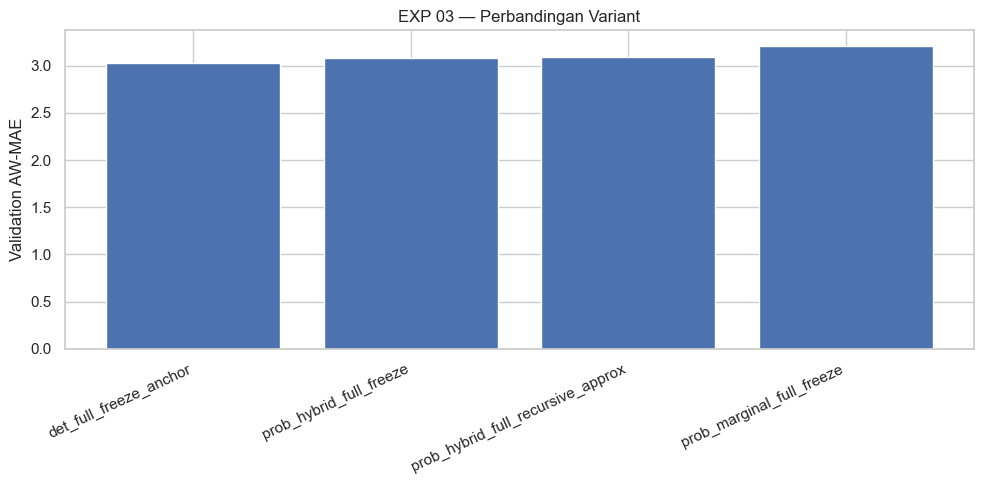

In [20]:

variant_metrics = pd.DataFrame([
    {
        "variant_name": "det_full_freeze_anchor",
        "branch_type": "safe",
        "model_type": "deterministic",
        "simulation_mode": "freeze",
        "valid_awmae": awmae_det_freeze,
        "decoder_params": json.dumps(best_params_det_freeze, default=float),
        "runtime_note": "freeze raw-output-first",
    },
    {
        "variant_name": "prob_marginal_full_freeze",
        "branch_type": "safe",
        "model_type": "probabilistic_marginal",
        "simulation_mode": "freeze",
        "valid_awmae": awmae_prob_freeze,
        "decoder_params": json.dumps(best_params_prob_freeze, default=float),
        "runtime_note": "freeze raw-output-first",
    },
    {
        "variant_name": "prob_hybrid_full_freeze",
        "branch_type": "safe",
        "model_type": "probabilistic_hybrid",
        "simulation_mode": "freeze",
        "valid_awmae": awmae_prob_hybrid_freeze,
        "decoder_params": json.dumps(best_params_prob_hybrid_freeze, default=float),
        "runtime_note": "freeze raw-output-first",
    },
    {
        "variant_name": "prob_hybrid_full_recursive_approx",
        "branch_type": "research",
        "model_type": "probabilistic_hybrid",
        "simulation_mode": "recursive_approx",
        "valid_awmae": awmae_prob_recursive_approx,
        "decoder_params": json.dumps(best_params_prob_recursive_approx, default=float),
        "runtime_note": "research-only approximate",
    },
]).sort_values("valid_awmae").reset_index(drop=True)

variant_metrics.to_csv(SUM_DIR / "variant_metrics.csv", index=False)
display(variant_metrics)

plt.figure(figsize=(10, 5))
plt.bar(variant_metrics["variant_name"], variant_metrics["valid_awmae"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("Validation AW-MAE")
plt.title("EXP 03 — Perbandingan Variant")
plt.tight_layout()
plt.savefig(FIG_DIR / "awmae_variant_comparison.png", dpi=150)
plt.show()


## 17. Raw Signal & Uncertainty Analysis


,variant,outcome_accuracy,goal_a_mae,goal_b_mae,total_goals_mae,goal_diff_mae,avg_entropy_outcome,avg_entropy_goal_a,avg_entropy_goal_b
0,det_full_freeze_anchor,0.585428,1.050112,1.081173,1.569885,1.597331,NaN,NaN,NaN
1,prob_marginal_full_freeze,0.585428,1.463348,1.389679,2.182125,1.671321,1.088435,1.918144,1.885130
2,prob_hybrid_full_freeze,0.585428,1.463348,1.389679,2.182125,1.671321,1.088435,1.918144,1.885130
3,prob_hybrid_full_recursive_approx,0.583143,1.440005,1.375388,2.130563,1.682011,1.089514,1.907223,1.871356


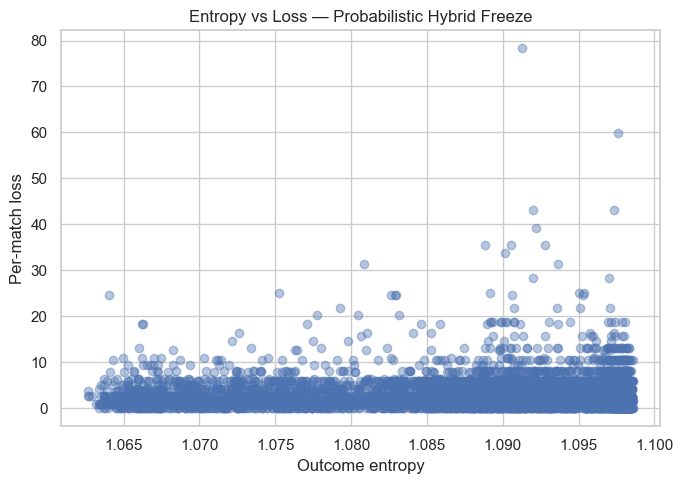

In [21]:

def entropy_from_prob_cols(df: pd.DataFrame, prefix: str) -> pd.Series:
    cols = [c for c in df.columns if c.startswith(prefix)]
    arr = df[cols].fillna(0).to_numpy(dtype=float)
    arr = np.clip(arr, 1e-12, 1.0)
    return pd.Series(-(arr * np.log(arr)).sum(axis=1), index=df.index)

raw_signal_rows = []

# Deterministic anchor signal
det_outcome_pred = raw_det_freeze[[f"pred_outcome_proba_{i}" for i in range(3)]].to_numpy().argmax(axis=1)
det_outcome_true = build_outcome_target(raw_det_freeze["actual_team_a_goals"], raw_det_freeze["actual_team_b_goals"])
raw_signal_rows.append({
    "variant": "det_full_freeze_anchor",
    "outcome_accuracy": accuracy_score(det_outcome_true, det_outcome_pred),
    "goal_a_mae": np.mean(np.abs(raw_det_freeze["actual_team_a_goals"] - raw_det_freeze["pred_goal_a_cont"])),
    "goal_b_mae": np.mean(np.abs(raw_det_freeze["actual_team_b_goals"] - raw_det_freeze["pred_goal_b_cont"])),
    "total_goals_mae": np.mean(np.abs((raw_det_freeze["actual_team_a_goals"] + raw_det_freeze["actual_team_b_goals"]) - raw_det_freeze["pred_total_cont"])),
    "goal_diff_mae": np.mean(np.abs((raw_det_freeze["actual_team_a_goals"] - raw_det_freeze["actual_team_b_goals"]) - raw_det_freeze["pred_gd_cont"])),
    "avg_entropy_outcome": np.nan,
    "avg_entropy_goal_a": np.nan,
    "avg_entropy_goal_b": np.nan,
})

for name, raw_df in [
    ("prob_marginal_full_freeze", raw_prob_freeze),
    ("prob_hybrid_full_freeze", raw_prob_freeze),
    ("prob_hybrid_full_recursive_approx", raw_prob_recursive_approx),
]:
    prob_out = raw_df[[c for c in raw_df.columns if c.startswith("prob_outcome__")]].to_numpy()
    outcome_pred = prob_out.argmax(axis=1)
    outcome_true = build_outcome_target(raw_df["actual_team_a_goals"], raw_df["actual_team_b_goals"])
    exp_total = raw_df["exp_goal_a"] + raw_df["exp_goal_b"]

    raw_signal_rows.append({
        "variant": name,
        "outcome_accuracy": accuracy_score(outcome_true, outcome_pred),
        "goal_a_mae": np.mean(np.abs(raw_df["actual_team_a_goals"] - raw_df["exp_goal_a"])),
        "goal_b_mae": np.mean(np.abs(raw_df["actual_team_b_goals"] - raw_df["exp_goal_b"])),
        "total_goals_mae": np.mean(np.abs((raw_df["actual_team_a_goals"] + raw_df["actual_team_b_goals"]) - exp_total)),
        "goal_diff_mae": np.mean(np.abs((raw_df["actual_team_a_goals"] - raw_df["actual_team_b_goals"]) - (raw_df["exp_goal_a"] - raw_df["exp_goal_b"]))),
        "avg_entropy_outcome": float(entropy_from_prob_cols(raw_df, "prob_outcome__").mean()),
        "avg_entropy_goal_a": float(entropy_from_prob_cols(raw_df, "prob_goal_a__").mean()),
        "avg_entropy_goal_b": float(entropy_from_prob_cols(raw_df, "prob_goal_b__").mean()),
    })

raw_signal_df = pd.DataFrame(raw_signal_rows)
display(raw_signal_df)

tmp_entropy = valid_pred_match_prob_hybrid_freeze.merge(
    entropy_from_prob_cols(raw_prob_freeze, "prob_outcome__").rename("outcome_entropy"),
    left_index=True,
    right_index=True,
)
tmp_entropy["match_loss"] = [
    official_match_loss(a, b, c, d)
    for a, b, c, d in zip(
        tmp_entropy["actual_team_a_goals"], tmp_entropy["actual_team_b_goals"],
        tmp_entropy["pred_team_a_goals"], tmp_entropy["pred_team_b_goals"]
    )
]
plt.figure(figsize=(7, 5))
plt.scatter(tmp_entropy["outcome_entropy"], tmp_entropy["match_loss"], alpha=0.4)
plt.xlabel("Outcome entropy")
plt.ylabel("Per-match loss")
plt.title("Entropy vs Loss — Probabilistic Hybrid Freeze")
plt.tight_layout()
plt.savefig(FIG_DIR / "entropy_vs_loss_analysis.png", dpi=150)
plt.show()


## 18. Calibration / Reliability Check Ringan


,bin,mean_prob,empirical_rate,count
0,"(0.2, 0.3]",0.288078,0.120287,2228
1,"(0.3, 0.4]",0.313504,0.241062,5650


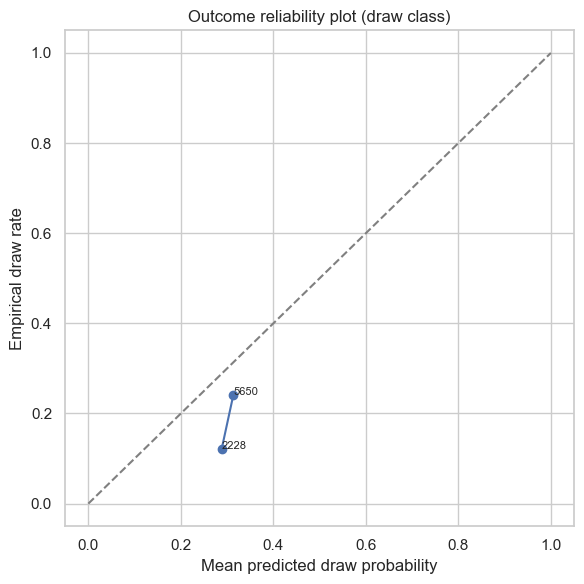

In [22]:

def make_reliability_table_binary(prob_true: pd.Series, y_true: pd.Series, bins: int = 10) -> pd.DataFrame:
    df = pd.DataFrame({"prob": prob_true, "y": y_true}).dropna()
    df["bin"] = pd.cut(df["prob"], bins=np.linspace(0, 1, bins + 1), include_lowest=True)
    tab = df.groupby("bin").agg(
        mean_prob=("prob", "mean"),
        empirical_rate=("y", "mean"),
        count=("y", "size"),
    ).reset_index()
    return tab

draw_true = (build_outcome_target(raw_prob_freeze["actual_team_a_goals"], raw_prob_freeze["actual_team_b_goals"]) == 1).astype(int)
draw_prob = raw_prob_freeze["prob_outcome__1"].astype(float)
reliability_tab = make_reliability_table_binary(draw_prob, draw_true, bins=10)
display(reliability_tab)

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.plot(reliability_tab["mean_prob"], reliability_tab["empirical_rate"], marker="o")
for _, row in reliability_tab.iterrows():
    plt.text(row["mean_prob"], row["empirical_rate"], str(int(row["count"])), fontsize=8)
plt.xlabel("Mean predicted draw probability")
plt.ylabel("Empirical draw rate")
plt.title("Outcome reliability plot (draw class)")
plt.tight_layout()
plt.savefig(FIG_DIR / "outcome_reliability_plot.png", dpi=150)
plt.show()


## 19. Feature Importance Shift Analysis


,model,identity_share
0,deterministic_outcome_anchor,0.208660
1,probabilistic_outcome_clf,0.208660
2,probabilistic_goal_a_bucket_clf,0.288452


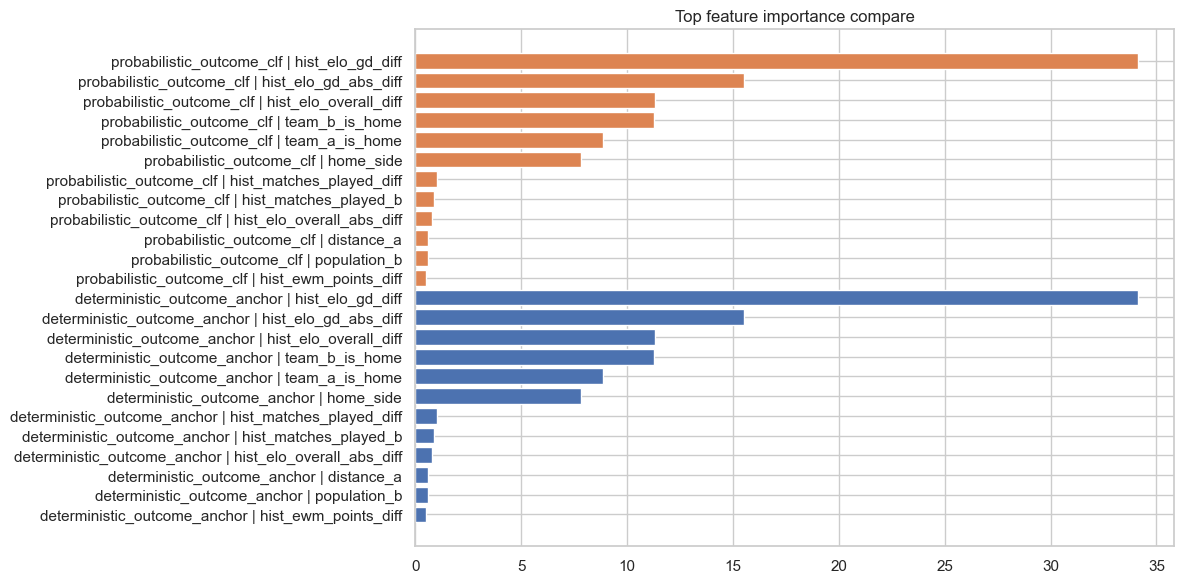

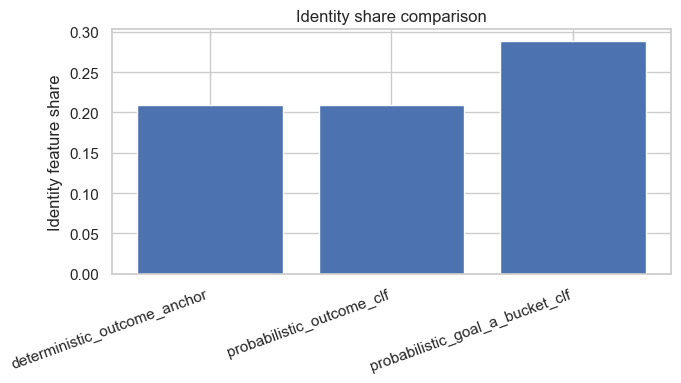

In [23]:

def _importance_df(model, feature_cols):
    imp = model.get_feature_importance()
    return pd.DataFrame({"feature": feature_cols, "importance": imp}).sort_values("importance", ascending=False).reset_index(drop=True)

imp_det_outcome = _importance_df(deterministic_bundle["outcome"], full_feature_cols)
imp_prob_outcome = _importance_df(prob_bundle["outcome_clf"], full_feature_cols)
imp_prob_goal_a = _importance_df(prob_bundle["goal_a_bucket_clf"], full_feature_cols)

def identity_share(imp_df: pd.DataFrame) -> float:
    identity_keywords = ["team_a", "team_b", "pair_key", "match_year", "tournament", "venue_country"]
    total = imp_df["importance"].sum()
    mask = imp_df["feature"].astype(str).apply(lambda x: any(k in x for k in identity_keywords))
    share = imp_df.loc[mask, "importance"].sum() / total if total > 0 else np.nan
    return float(share)

identity_share_df = pd.DataFrame([
    {"model": "deterministic_outcome_anchor", "identity_share": identity_share(imp_det_outcome)},
    {"model": "probabilistic_outcome_clf", "identity_share": identity_share(imp_prob_outcome)},
    {"model": "probabilistic_goal_a_bucket_clf", "identity_share": identity_share(imp_prob_goal_a)},
])
display(identity_share_df)

top_plot = pd.concat([
    imp_det_outcome.head(12).assign(model="deterministic_outcome_anchor"),
    imp_prob_outcome.head(12).assign(model="probabilistic_outcome_clf"),
], ignore_index=True)

plt.figure(figsize=(12, 6))
for i, model_name in enumerate(top_plot["model"].unique()):
    sub = top_plot[top_plot["model"] == model_name].copy().sort_values("importance")
    plt.barh([f"{model_name} | {f}" for f in sub["feature"]], sub["importance"])
plt.title("Top feature importance compare")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_importance_compare.png", dpi=150)
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(identity_share_df["model"], identity_share_df["identity_share"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("Identity feature share")
plt.title("Identity share comparison")
plt.tight_layout()
plt.savefig(FIG_DIR / "identity_share_comparison.png", dpi=150)
plt.show()


## 20. Subgroup Error Analysis


,variant,group_type,group_value,awmae_subgroup
0,det_full_freeze_anchor,gender,M,2.776179
1,det_full_freeze_anchor,gender,W,3.793877
2,det_full_freeze_anchor,neutral,0,2.810262
3,det_full_freeze_anchor,neutral,1,3.515050
4,det_full_freeze_anchor,extreme,normal,2.825942
5,det_full_freeze_anchor,extreme,extreme,5.846238
6,det_full_freeze_anchor,tournament,Friendly,2.751066
7,det_full_freeze_anchor,tournament,FIFA World Cup qualification,2.651125
8,det_full_freeze_anchor,tournament,UEFA Euro qualification,2.739768
9,det_full_freeze_anchor,tournament,African Cup of Nations qualification,2.592207


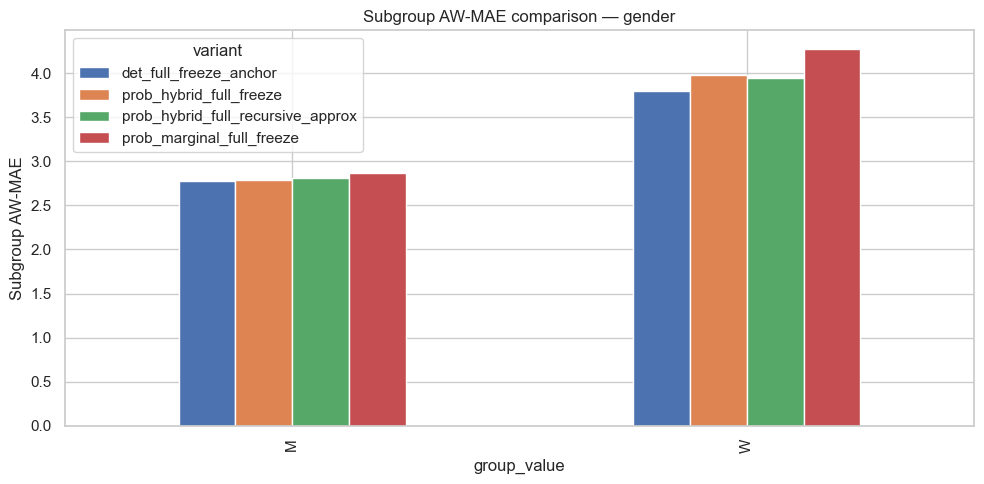

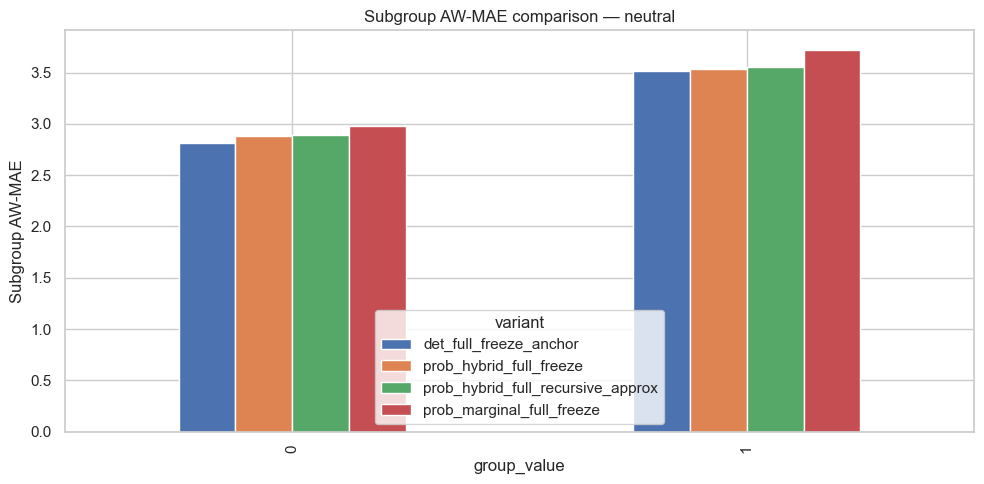

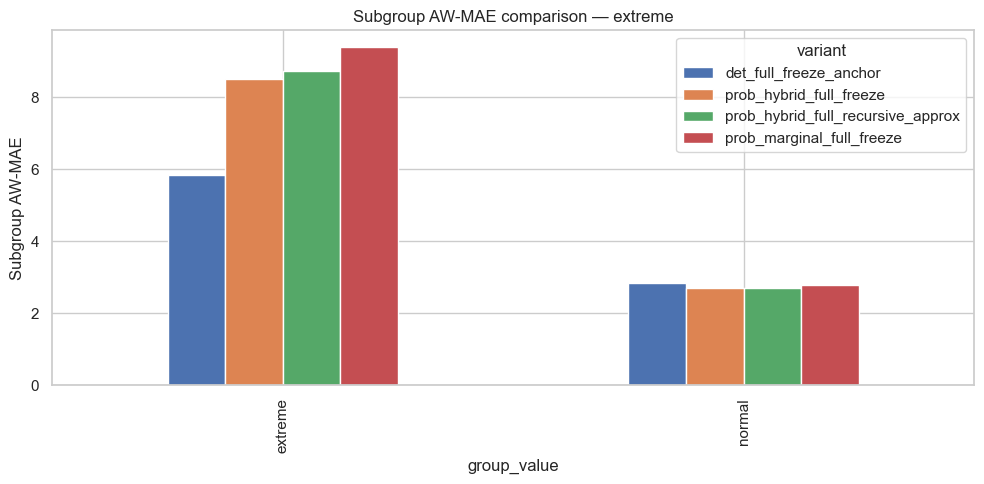

In [24]:
def add_loss_columns(pred_df: pd.DataFrame) -> pd.DataFrame:
    out = pred_df.copy()
    out["match_loss"] = [
        official_match_loss(a, b, c, d)
        for a, b, c, d in zip(
            out["actual_team_a_goals"], out["actual_team_b_goals"],
            out["pred_team_a_goals"], out["pred_team_b_goals"],
        )
    ]
    out["weight"] = out["tournament"].apply(get_tournament_weight)
    return out


subgroup_base = valid_fold_base[["match_id", "gender", "neutral", "tournament", "team_a_goals", "team_b_goals"]].copy()
subgroup_base["is_extreme"] = (
    subgroup_base[["team_a_goals", "team_b_goals"]].max(axis=1) >= 6
).astype(int)

variant_pred_map = {
    "det_full_freeze_anchor": add_loss_columns(valid_pred_match_det_freeze),
    "prob_marginal_full_freeze": add_loss_columns(valid_pred_match_prob_freeze),
    "prob_hybrid_full_freeze": add_loss_columns(valid_pred_match_prob_hybrid_freeze),
    "prob_hybrid_full_recursive_approx": add_loss_columns(valid_pred_match_prob_recursive_approx),
}

def subgroup_awmae(tmp: pd.DataFrame) -> float:
    w = tmp["weight"].astype(float).to_numpy()
    l = tmp["match_loss"].astype(float).to_numpy()
    return float(np.sum(w * l) / np.sum(w))

subgroup_rows = []
for variant_name, pred_df in variant_pred_map.items():
    tmp = subgroup_base.merge(pred_df[["match_id", "match_loss", "weight"]], on="match_id", how="left")

    for gender, gdf in tmp.groupby("gender"):
        subgroup_rows.append({"variant": variant_name, "group_type": "gender", "group_value": gender, "awmae_subgroup": subgroup_awmae(gdf)})
    for neutral, gdf in tmp.groupby("neutral"):
        subgroup_rows.append({"variant": variant_name, "group_type": "neutral", "group_value": str(neutral), "awmae_subgroup": subgroup_awmae(gdf)})
    for ext, gdf in tmp.groupby("is_extreme"):
        subgroup_rows.append({"variant": variant_name, "group_type": "extreme", "group_value": "extreme" if ext == 1 else "normal", "awmae_subgroup": subgroup_awmae(gdf)})
    top_tournaments = tmp["tournament"].value_counts().head(8).index.tolist()
    for tourn in top_tournaments:
        gdf = tmp[tmp["tournament"] == tourn]
        subgroup_rows.append({"variant": variant_name, "group_type": "tournament", "group_value": tourn, "awmae_subgroup": subgroup_awmae(gdf)})

subgroup_df = pd.DataFrame(subgroup_rows)
display(subgroup_df.head(20))

for group_type, fname in [
    ("gender", "subgroup_awmae_gender.png"),
    ("neutral", "subgroup_awmae_neutral.png"),
    ("extreme", "subgroup_awmae_extreme.png"),
]:
    plot_df = subgroup_df[subgroup_df["group_type"] == group_type].copy()
    pivot = plot_df.pivot(index="group_value", columns="variant", values="awmae_subgroup")
    pivot.plot(kind="bar", figsize=(10, 5))
    plt.ylabel("Subgroup AW-MAE")
    plt.title(f"Subgroup AW-MAE comparison — {group_type}")
    plt.tight_layout()
    plt.savefig(FIG_DIR / fname, dpi=150)
    plt.show()


## 21. Keputusan Eksperimen


In [25]:

safe_variants = variant_metrics[variant_metrics["branch_type"] == "safe"].sort_values("valid_awmae").reset_index(drop=True)
research_variants = variant_metrics[variant_metrics["branch_type"] == "research"].sort_values("valid_awmae").reset_index(drop=True)

best_safe_row = safe_variants.iloc[0].to_dict()
best_research_row = research_variants.iloc[0].to_dict() if len(research_variants) > 0 else None

print("[DECISION] Best submission-safe pipeline:")
print(best_safe_row["variant_name"], "| AW-MAE =", round(float(best_safe_row["valid_awmae"]), 6))

print("\n[DECISION] Best research-only pipeline:")
if best_research_row is None:
    print("Tidak ada research variant yang dijalankan.")
else:
    print(best_research_row["variant_name"], "| AW-MAE =", round(float(best_research_row["valid_awmae"]), 6))

notes = []
notes.append("EXP 03 decisions")
notes.append(f"Best safe variant: {best_safe_row['variant_name']} | AW-MAE={float(best_safe_row['valid_awmae']):.6f}")
if best_research_row is not None:
    notes.append(f"Best research variant: {best_research_row['variant_name']} | AW-MAE={float(best_research_row['valid_awmae']):.6f}")
notes.append("Freeze branch remains submission-safe.")
notes.append("Recursive approx remains research-only and approximate.")
with open(SUM_DIR / "experiment_notes.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(notes))


[DECISION] Best submission-safe pipeline:
det_full_freeze_anchor | AW-MAE = 3.027458

[DECISION] Best research-only pipeline:
prob_hybrid_full_recursive_approx | AW-MAE = 3.094592


## 22. Retrain Best Safe Variant pada Full Train


In [26]:

# Build full-train full-history features actual pre-match
train_full_history_df, full_train_team_states_cutoff, full_train_h2h_states_cutoff = build_train_history_features_full(train_match_base)
train_full_all = (
    train_match_base
    .merge(train_static_df.drop(columns=["date", "gender", "tournament", "venue_country", "neutral",
                                         "team_a", "team_b", "team_a_is_home", "team_b_is_home",
                                         "team_a_goals", "team_b_goals",
                                         "team_a_confederation", "team_b_confederation",
                                         "team_a_population", "team_b_population",
                                         "team_a_gdp_per_capita", "team_b_gdp_per_capita",
                                         "team_a_distance_travel", "team_b_distance_travel",
                                         "altitude_venue", "temperature_venue"], errors="ignore"),
           on="match_id", how="left")
    .merge(train_full_history_df, on="match_id", how="left")
)

if best_safe_row["variant_name"] == "det_full_freeze_anchor":
    best_safe_models = train_deterministic_bundle(train_full_all, full_feature_cols, static_categorical_features)
    best_safe_decoder_type = "deterministic"
    best_safe_decoder_params = best_params_det_freeze
elif best_safe_row["variant_name"] == "prob_marginal_full_freeze":
    best_safe_models = train_probabilistic_bundle(train_full_all, full_feature_cols, static_categorical_features)
    best_safe_decoder_type = "prob_marginal"
    best_safe_decoder_params = best_params_prob_freeze
else:
    best_safe_models = train_probabilistic_bundle(train_full_all, full_feature_cols, static_categorical_features)
    best_safe_decoder_type = "prob_hybrid"
    best_safe_decoder_params = best_params_prob_hybrid_freeze

print(f"[INFO] Best safe variant diretrain: {best_safe_row['variant_name']}")


build_train_history_full:   0%|          | 0/39386 [00:00<?, ?it/s]

0:	learn: 1.7841695	test: 1.6076744	best: 1.6076744 (0)	total: 411ms	remaining: 10m 15s
200:	learn: 1.3889915	test: 1.3079148	best: 1.3079148 (200)	total: 35.4s	remaining: 3m 49s
400:	learn: 1.3344991	test: 1.3066655	best: 1.3057317 (307)	total: 1m 7s	remaining: 3m 5s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 1.305731711
bestIteration = 307

Shrink model to first 308 iterations.
0:	learn: 1.7760469	test: 1.9057994	best: 1.9057994 (0)	total: 224ms	remaining: 5m 36s
200:	learn: 1.3968215	test: 1.4982651	best: 1.4982651 (200)	total: 27.8s	remaining: 2m 59s
400:	learn: 1.3594898	test: 1.4888700	best: 1.4888675 (399)	total: 51.8s	remaining: 2m 21s
600:	learn: 1.3245243	test: 1.4861711	best: 1.4858739 (592)	total: 1m 20s	remaining: 2m 1s
800:	learn: 1.2964020	test: 1.4846696	best: 1.4846304 (797)	total: 1m 50s	remaining: 1m 36s
1000:	learn: 1.2645106	test: 1.4831319	best: 1.4830676 (998)	total: 2m 21s	remaining: 1m 10s
1200:	learn: 1.2345737	test: 1.4833895	best: 1.4

## 23. Test Inference


In [27]:

test_static_all = test_static_df.copy()

if best_safe_decoder_type == "deterministic":
    raw_test_safe = simulate_freeze_det_raw_outputs(
        test_match_base,
        test_static_all,
        full_train_team_states_cutoff,
        full_train_h2h_states_cutoff,
        best_safe_models,
    )
    pred_rows = []
    for _, row in raw_test_safe.iterrows():
        pair = decode_single_match_score(
            pred_goal_a=float(row["pred_goal_a_cont"]),
            pred_goal_b=float(row["pred_goal_b_cont"]),
            pred_total=float(row["pred_total_cont"]),
            pred_gd=float(row["pred_gd_cont"]),
            pred_outcome_proba=np.array([row["pred_outcome_proba_0"], row["pred_outcome_proba_1"], row["pred_outcome_proba_2"]], dtype=float),
            scoreline_prior=scoreline_prior_cache,
            max_goals=int(best_safe_decoder_params["MAX_GOALS"]),
            w_direct=float(best_safe_decoder_params["w_direct"]),
            w_total=float(best_safe_decoder_params["w_total"]),
            w_gd=float(best_safe_decoder_params["w_gd"]),
            w_outcome=float(best_safe_decoder_params["w_outcome"]),
            w_prior=float(best_safe_decoder_params["w_prior"]),
        )
        pred_rows.append({"match_id": row["match_id"], "pred_team_a_goals": pair[0], "pred_team_b_goals": pair[1]})
    test_pred_match_best_safe = raw_test_safe.merge(pd.DataFrame(pred_rows), on="match_id", how="left")
else:
    raw_test_safe = simulate_freeze_prob_raw_outputs(
        test_match_base,
        test_static_all,
        full_train_team_states_cutoff,
        full_train_h2h_states_cutoff,
        best_safe_models,
    )
    pred_rows = []
    for _, row in raw_test_safe.iterrows():
        pair = decode_single_match_probabilistic(
            raw_row=row,
            decoder_params=best_safe_decoder_params,
            scoreline_prior=scoreline_prior_cache,
            max_candidate_goal=int(best_safe_decoder_params["max_candidate_goal"]),
        )
        pred_rows.append({"match_id": row["match_id"], "pred_team_a_goals": pair[0], "pred_team_b_goals": pair[1]})
    test_pred_match_best_safe = raw_test_safe.merge(pd.DataFrame(pred_rows), on="match_id", how="left")

test_pred_match_best_safe.to_csv(PRED_DIR / "test_pred_match_best_safe.csv", index=False)
print("[OK] test_pred_match_best_safe.csv disimpan.")

# Research-only inference (opsional tapi dijalankan karena branch research diuji)
best_research_models = train_probabilistic_bundle(train_full_all, full_feature_cols, static_categorical_features)
raw_test_research, _ = simulate_recursive_prob_approx(
    test_match_base,
    test_static_all,
    full_train_team_states_cutoff,
    full_train_h2h_states_cutoff,
    best_research_models,
    default_recursive_prob_params,
    scoreline_prior_cache,
)

pred_rows_research = []
for _, row in raw_test_research.iterrows():
    pair = decode_single_match_probabilistic(
        raw_row=row,
        decoder_params=best_params_prob_recursive_approx,
        scoreline_prior=scoreline_prior_cache,
        max_candidate_goal=int(best_params_prob_recursive_approx["max_candidate_goal"]),
    )
    pred_rows_research.append({"match_id": row["match_id"], "pred_team_a_goals": pair[0], "pred_team_b_goals": pair[1]})

test_pred_match_best_research = raw_test_research.merge(pd.DataFrame(pred_rows_research), on="match_id", how="left")
test_pred_match_best_research.to_csv(PRED_DIR / "test_pred_match_best_research.csv", index=False)
print("[OK] test_pred_match_best_research.csv disimpan (research-only).")


freeze_det_raw:   0%|          | 0/21211 [00:00<?, ?it/s]

[OK] test_pred_match_best_safe.csv disimpan.
0:	learn: 2.1647648	test: 2.1736663	best: 2.1736663 (0)	total: 1.16s	remaining: 28m 52s
200:	learn: 1.5688526	test: 1.9556957	best: 1.8895083 (50)	total: 4m 53s	remaining: 31m 34s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 1.889508311
bestIteration = 50

Shrink model to first 51 iterations.
0:	learn: 2.1649198	test: 2.1721979	best: 2.1721979 (0)	total: 839ms	remaining: 20m 57s
200:	learn: 1.5820693	test: 1.8805833	best: 1.8445541 (62)	total: 4m 50s	remaining: 31m 16s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 1.844554073
bestIteration = 62

Shrink model to first 63 iterations.
0:	learn: 1.0964773	test: 1.0965303	best: 1.0965303 (0)	total: 458ms	remaining: 11m 27s
200:	learn: 1.0215435	test: 1.0481296	best: 1.0477029 (134)	total: 1m 31s	remaining: 9m 50s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 1.047702928
bestIteration = 134

Shrink model to first 135 iterations.
0:	le

recursive_prob_approx:   0%|          | 0/21211 [00:00<?, ?it/s]

[OK] test_pred_match_best_research.csv disimpan (research-only).


## 24. Reverse Mapping ke Submission


In [28]:

submission_safe = match_predictions_to_submission(
    test,
    test_pred_match_best_safe[["match_id", "pred_team_a_goals", "pred_team_b_goals"]]
    .merge(test_match_base[["match_id", "team_a", "team_b"]], on="match_id", how="left"),
)
assert len(submission_safe) == len(sample_sub), "Row count submission safe tidak cocok."
assert list(submission_safe.columns) == ["Id", "team_goals", "opp_goals"], "Kolom submission safe tidak sesuai."
assert submission_safe["Id"].tolist() == sample_sub["Id"].tolist(), "Urutan Id submission safe tidak sinkron."
assert not submission_safe[["team_goals", "opp_goals"]].isna().any().any(), "Ada missing pada submission safe."
submission_safe.to_csv(SUB_DIR / "submission_exp03_best_safe.csv", index=False)

submission_research = match_predictions_to_submission(
    test,
    test_pred_match_best_research[["match_id", "pred_team_a_goals", "pred_team_b_goals"]]
    .merge(test_match_base[["match_id", "team_a", "team_b"]], on="match_id", how="left"),
)
assert len(submission_research) == len(sample_sub), "Row count submission research tidak cocok."
assert list(submission_research.columns) == ["Id", "team_goals", "opp_goals"], "Kolom submission research tidak sesuai."
assert submission_research["Id"].tolist() == sample_sub["Id"].tolist(), "Urutan Id submission research tidak sinkron."
assert not submission_research[["team_goals", "opp_goals"]].isna().any().any(), "Ada missing pada submission research."
submission_research.to_csv(SUB_DIR / "submission_exp03_best_research.csv", index=False)

print("[OK] submission_exp03_best_safe.csv disimpan.")
print("[OK] submission_exp03_best_research.csv disimpan (research-only).")
display(submission_safe.head())


[OK] submission_exp03_best_safe.csv disimpan.
[OK] submission_exp03_best_research.csv disimpan (research-only).


,Id,team_goals,opp_goals
0,M034984_Seychelles,2,1
1,M034984_Mauritius,1,2
2,M034985_Comoros,1,2
3,M034985_Maldives,2,1
4,M034986_Réunion,2,1


## 25. Ringkasan Hasil Eksperimen


Pada akhir run notebook ini, ada beberapa pertanyaan yang harus dijawab secara eksplisit dari hasil tabel dan artefak:

1. apakah **probabilistic modeling** benar-benar mengalahkan deterministic anchor?
2. apakah **hybrid** lebih baik daripada **marginal-only**?
3. apakah **recursive approx** memberi tambahan yang nyata, atau hanya tipis dan tetap terlalu berisiko untuk dijadikan branch aman?
4. mana yang paling layak menjadi **submission-safe pipeline**?
5. mana yang cukup menarik untuk diteruskan sebagai **research-only branch**?

Kalau probabilistic freeze memberi gain yang konsisten, maka langkah berikutnya yang masuk akal adalah **refinement / calibration / joint scoreline modeling**.  
Kalau gain probabilistic tipis atau tidak stabil, maka eksperimen sesudah ini bisa lebih produktif bila diarahkan ke **distillation / train-only signal transfer**.
